# E-Commerce Time Series Analysis & Forecasting
### Sales Data 2019 

Gibran Ariq Natakusuma

DSML-41



**Metadata:**
| Kolom | Deskripsi |
|-------|-----------|
| Order ID | ID pesanan |
| Product | Nama produk |
| Quantity Ordered | Jumlah produk terjual |
| Price Each | Harga jual per unit |
| Order Date | Tanggal pesanan |
| Purchase Address | Alamat pembelian |
| City | Kota transaksi |
| PostalCode | Kode pos |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print("Semua library berhasil di-import!")


Semua library berhasil di-import!


---
## Tahap 1: Eksplorasi dan Pembersihan Data


In [2]:
df = pd.read_csv('../dataset/ecommerce_time_series_analysis/sales_data_2019_all_cleaned.csv')
print(f"Dataset: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.head()


Dataset: 185,950 baris × 8 kolom


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,PostalCode
0,141234,iPhone,1,700.00,01/22/19 21:25,"944 Walnut St, Boston, MA 02215",Boston,2215
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035",Portland,97035
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016",San Francisco,94016
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001",Los Angeles,90001
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301",Austin,73301


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185950 non-null  int64  
 1   Product           185950 non-null  object 
 2   Quantity Ordered  185950 non-null  int64  
 3   Price Each        185950 non-null  float64
 4   Order Date        185950 non-null  object 
 5   Purchase Address  185950 non-null  object 
 6   City              185950 non-null  object 
 7   PostalCode        185950 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 11.3+ MB


In [4]:
# Konversi tipe data
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M')
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
print("Konversi tipe data selesai!")
print(df.dtypes)


Konversi tipe data selesai!
Order ID                     int64
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
City                        object
PostalCode                   int64
dtype: object


### Penanganan Missing Values
Sebelumnya sudah dilakukan pembersihan data di luar notebook ini. Terdapat **545 missing values** yang dihapus karena seluruh kolom pada baris tersebut kosong, sehingga keputusan yang tepat adalah melakukan drop.


In [5]:
print("Pengecekan Missing Values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("Data sudah bersih. 545 baris missing values telah di-drop sebelumnya (seluruh kolom kosong).")


Pengecekan Missing Values:
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
City                0
PostalCode          0
dtype: int64

Total missing values: 0
Data sudah bersih. 545 baris missing values telah di-drop sebelumnya (seluruh kolom kosong).


### Pengecekan Outlier


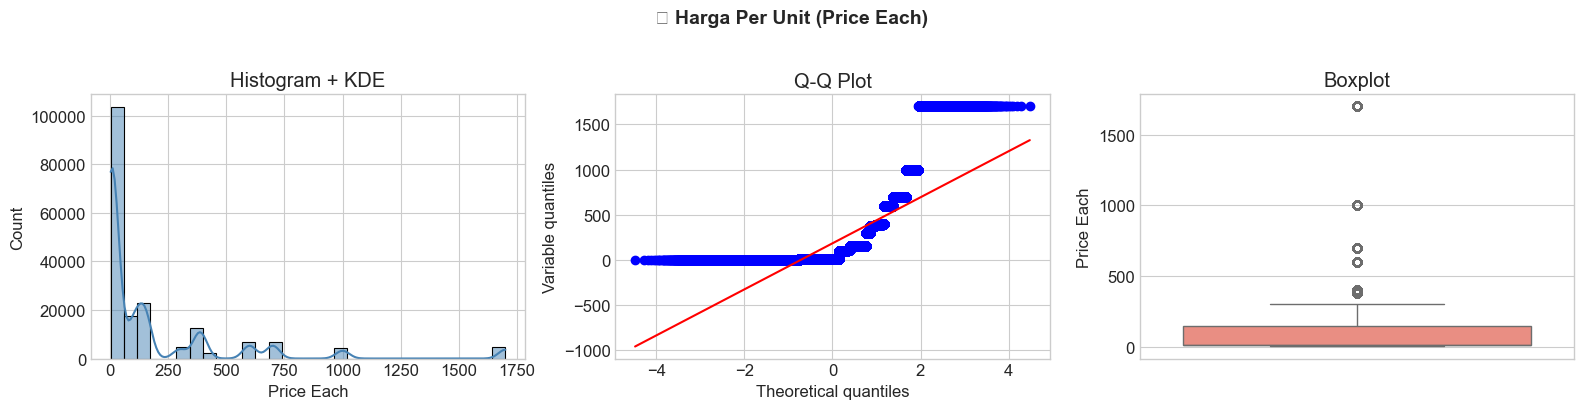

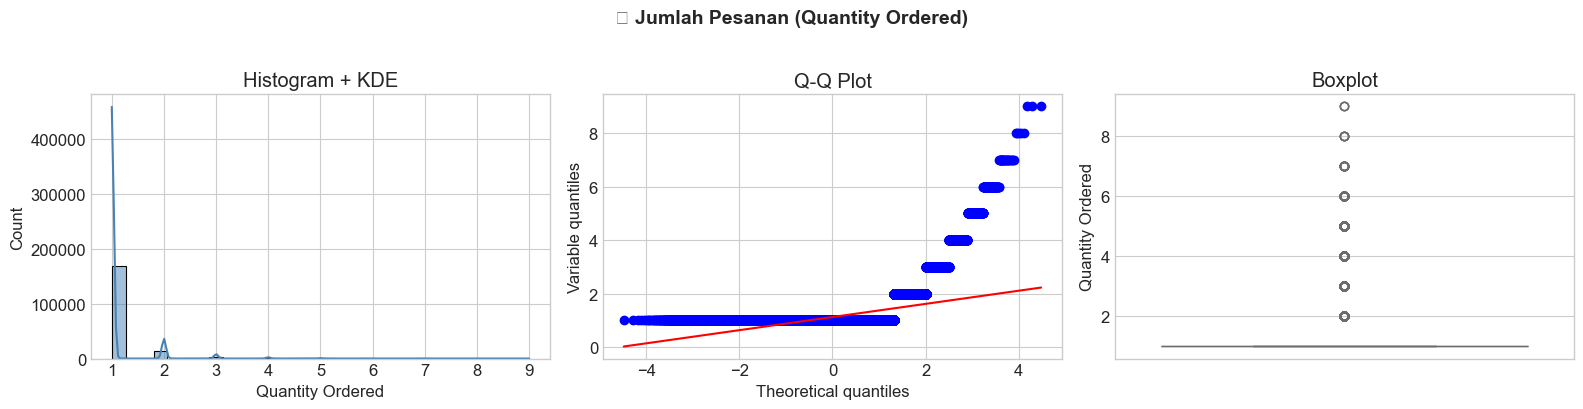

In [6]:
nama_fitur = {
    'Price Each': 'Harga Per Unit (Price Each)',
    'Quantity Ordered': 'Jumlah Pesanan (Quantity Ordered)'
}

def check_plot(df, columns):
    for variable in columns:
        plt.figure(figsize=(16, 4))
        plt.suptitle(f'📊 {nama_fitur.get(variable, variable)}', fontsize=14, fontweight='bold', y=1.02)
        plt.subplot(1, 3, 1)
        sns.histplot(df[variable], bins=30, kde=True, color='steelblue')
        plt.title('Histogram + KDE'); plt.xlabel(variable)
        plt.subplot(1, 3, 2)
        stats.probplot(df[variable], dist="norm", plot=plt)
        plt.title('Q-Q Plot'); plt.ylabel('Variable quantiles')
        plt.subplot(1, 3, 3)
        sns.boxplot(y=df[variable], color='salmon')
        plt.title('Boxplot')
        plt.tight_layout(); plt.show()

check_plot(df, ['Price Each', 'Quantity Ordered'])


### Insight Outlier
Outlier yang terdeteksi **wajar dan tidak perlu dihapus**:
- **Price Each**: Variasi harga wajar (baterai \$2.99 s/d laptop \$1,700)
- **Quantity Ordered**: Pembelian banyak wajar untuk produk kecil (baterai, kabel)


In [7]:
df = df.sort_values('Order Date').reset_index(drop=True)
print(f"Data diurutkan: {df['Order Date'].min()} → {df['Order Date'].max()}")


Data diurutkan: 2019-01-01 03:07:00 → 2020-01-01 05:13:00


Saya sempat mengecek dataset ternyata terdapat data 2020

In [8]:
# Filter data khusus tahun 2020
df_2020 = df[df['Order Date'].dt.year == 2020]

# Jika ingin melihat jumlah barisnya
print(f"Jumlah baris (transaksi) di tahun 2020: {len(df_2020)}")

# Memunculkan 5 sampel data teratas (jika datanya ada)
df_2020

Jumlah baris (transaksi) di tahun 2020: 34


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,PostalCode
185916,311386,iPhone,1,700.00,2020-01-01 00:10:00,"730 Pine St, San Francisco, CA 94016",San Francisco,94016
185917,311386,Apple Airpods Headphones,1,150.00,2020-01-01 00:10:00,"730 Pine St, San Francisco, CA 94016",San Francisco,94016
185918,300759,20in Monitor,1,109.99,2020-01-01 00:14:00,"193 5th St, Austin, TX 73301",Austin,73301
185919,302393,Lightning Charging Cable,1,14.95,2020-01-01 00:14:00,"108 Jefferson St, Boston, MA 02215",Boston,2215
185920,297817,iPhone,1,700.00,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",New York City,10001
185921,297817,Lightning Charging Cable,2,14.95,2020-01-01 00:22:00,"519 13th St, New York City, NY 10001",New York City,10001
185922,308322,Bose SoundSport Headphones,1,99.99,2020-01-01 00:24:00,"362 Willow St, San Francisco, CA 94016",San Francisco,94016
185923,297150,Lightning Charging Cable,1,14.95,2020-01-01 00:38:00,"427 Wilson St, Dallas, TX 75001",Dallas,75001
185924,319366,20in Monitor,2,109.99,2020-01-01 00:45:00,"746 South St, San Francisco, CA 94016",San Francisco,94016
185925,315138,AAA Batteries (4-pack),3,2.99,2020-01-01 00:51:00,"257 Adams St, New York City, NY 10001",New York City,10001


Data 2020 yang ditemukan hanya terdiri dari 1 hari (1 Januari 2020), kemungkinan berasal dari transaksi akhir Desember 2019 yang ter-record melewati pergantian tahun. Data ini didrop karena tidak representatif, keluar dari scope analisis 2019, dan berpotensi menyebabkan data leakage mengingat target forecasting adalah Januari 2020.

In [9]:
# Drop data di luar tahun 2019
df = df[df['Order Date'].dt.year == 2019]
print(f"Data setelah filter 2019: {df.shape[0]:,} baris")
print(f"   Range: {df['Order Date'].min()} → {df['Order Date'].max()}")

Data setelah filter 2019: 185,916 baris
   Range: 2019-01-01 03:07:00 → 2019-12-31 23:53:00


---
## Tahap 2: Feature Engineering


In [10]:
df['Revenue'] = df['Quantity Ordered'] * df['Price Each']
df['Hour'] = df['Order Date'].dt.hour
df['Day'] = df['Order Date'].dt.day
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Day_Name'] = df['Order Date'].dt.day_name()
df['Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Date'] = df['Order Date'].dt.date

print("Kolom baru: Revenue, Hour, Day, Month, Month_Name, Day_Name, Week, Date")
df[['Order ID','Product','Quantity Ordered','Price Each','Revenue','Hour','Month','Day_Name']].head(10)


Kolom baru: Revenue, Hour, Day, Month, Month_Name, Day_Name, Week, Date


,Order ID,Product,Quantity Ordered,Price Each,Revenue,Hour,Month,Day_Name
0,147268,Wired Headphones,1,11.99,11.99,3,1,Tuesday
1,148041,USB-C Charging Cable,1,11.95,11.95,3,1,Tuesday
2,149343,Apple Airpods Headphones,1,150.00,150.00,4,1,Tuesday
3,149964,AAA Batteries (4-pack),1,2.99,2.99,5,1,Tuesday
4,149350,USB-C Charging Cable,2,11.95,23.90,6,1,Tuesday
5,141732,iPhone,1,700.00,700.00,6,1,Tuesday
6,149620,Lightning Charging Cable,1,14.95,14.95,6,1,Tuesday
7,142451,AAA Batteries (4-pack),1,2.99,2.99,6,1,Tuesday
8,146039,34in Ultrawide Monitor,1,379.99,379.99,7,1,Tuesday
9,141316,AAA Batteries (4-pack),3,2.99,8.97,7,1,Tuesday


---
## Tahap 3: Analisis Deskriptif


### Q1: Statistik Utama Penjualan 2019


In [11]:
total_revenue = df['Revenue'].sum()
total_orders = df['Order ID'].nunique()
total_items = df['Quantity Ordered'].sum()
order_stats = df.groupby('Order ID').agg(items=('Quantity Ordered','sum'), spend=('Revenue','sum'))
avg_items = order_stats['items'].mean()
avg_spend = order_stats['spend'].mean()

print("="*60)
print("STATISTIK UTAMA PENJUALAN 2019")
print("="*60)
print(f"  Total Revenue          : ${total_revenue:,.2f}")
print(f"  Total Order            : {total_orders:,}")
print(f"  Total Barang Terjual   : {total_items:,.0f}")
print(f"  Rata-rata Barang/Txn   : {avg_items:.2f}")
print(f"  Rata-rata Spending/Txn : ${avg_spend:,.2f}")
print("="*60)
print(f"\nInsight: Revenue ${total_revenue:,.0f} dari {total_orders:,} order, avg {avg_items:.1f} item dan ${avg_spend:,.0f}/txn.")


STATISTIK UTAMA PENJUALAN 2019
  Total Revenue          : $34,483,365.68
  Total Order            : 178,406
  Total Barang Terjual   : 209,038
  Rata-rata Barang/Txn   : 1.17
  Rata-rata Spending/Txn : $193.29

Insight: Revenue $34,483,366 dari 178,406 order, avg 1.2 item dan $193/txn.


### Q2: Jumlah Order Harian, Mingguan, Bulanan

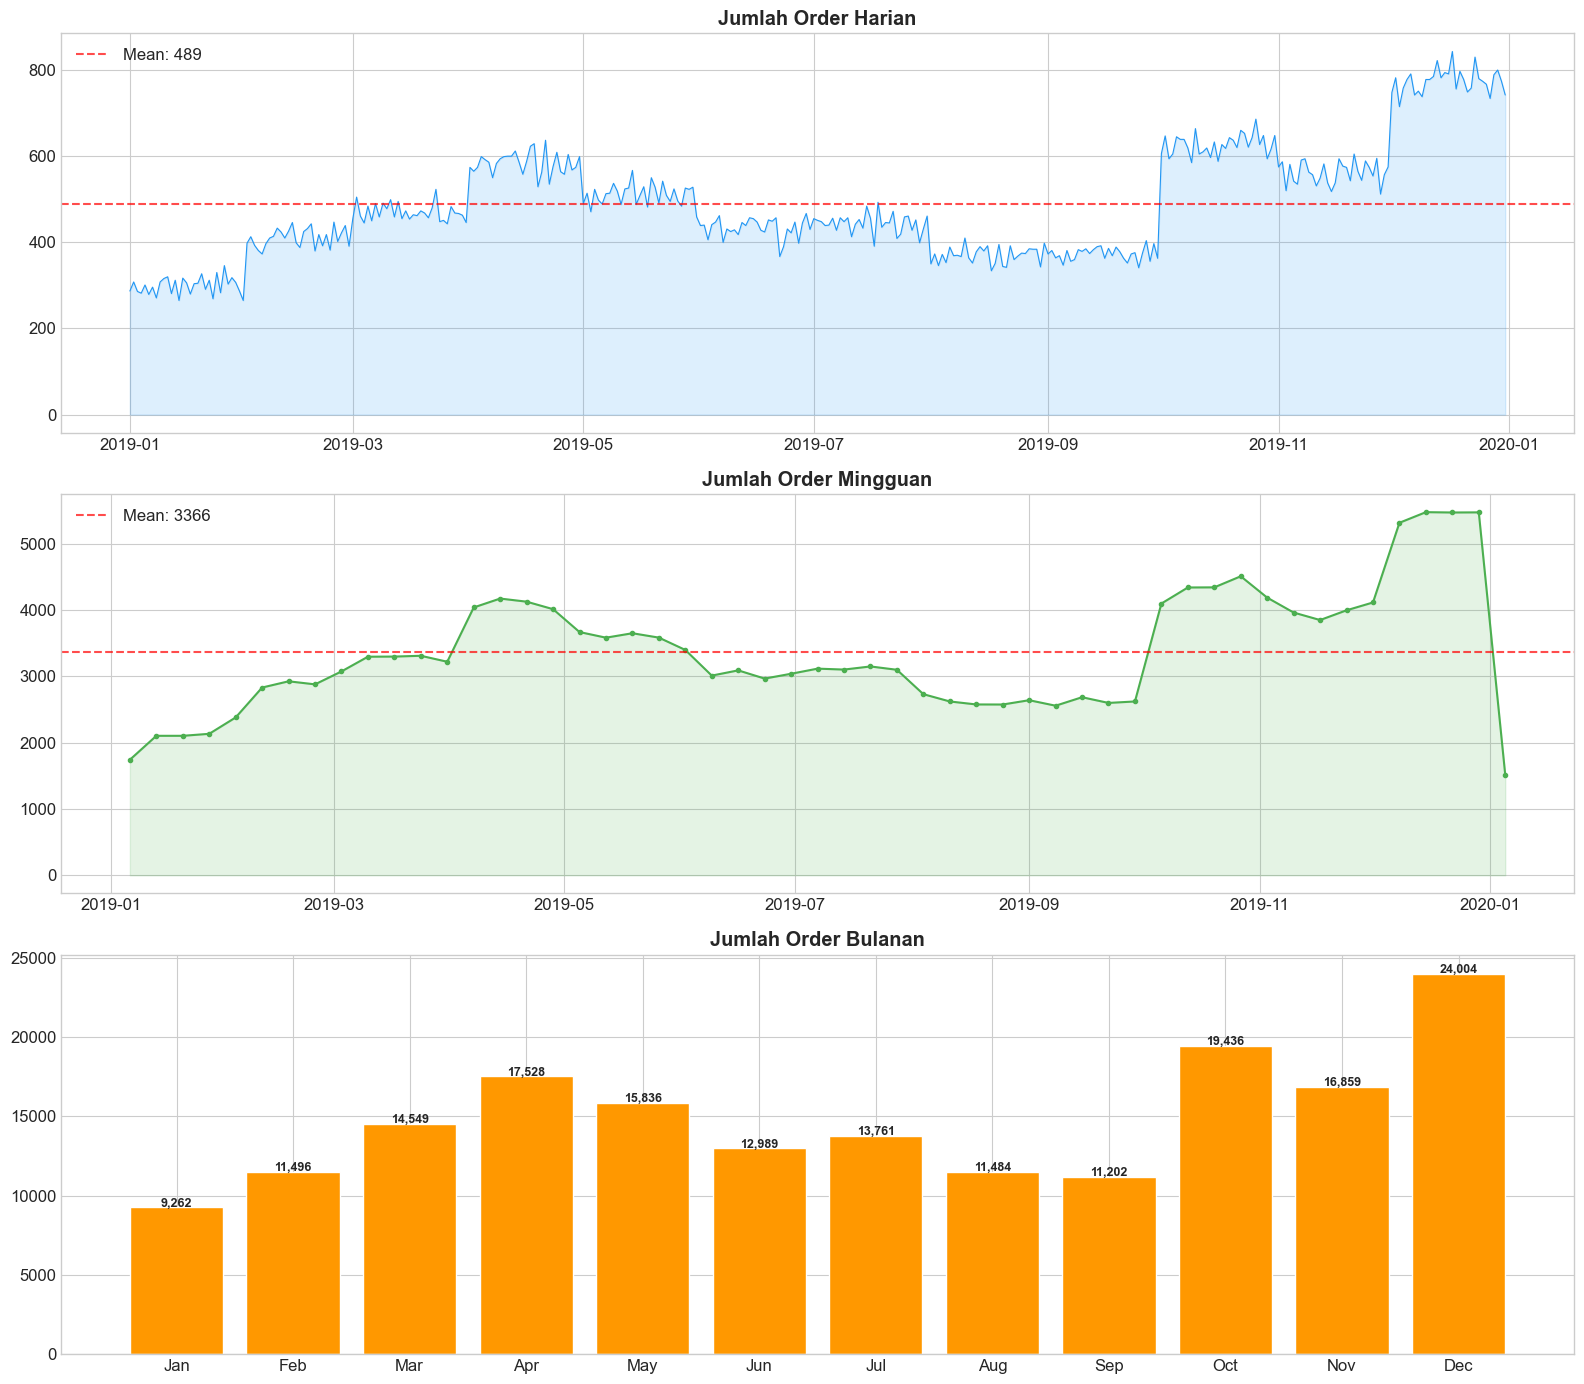

Harian avg: 489 | Mingguan avg: 3366
   Tertinggi: December (24,004) | Terendah: January (9,262)
   Tren meningkat di Q4 (holiday season).


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

daily_orders = df.groupby('Date')['Order ID'].nunique()
axes[0].plot(daily_orders.index, daily_orders.values, color='#2196F3', linewidth=0.8)
axes[0].fill_between(daily_orders.index, daily_orders.values, alpha=0.15, color='#2196F3')
axes[0].set_title('Jumlah Order Harian', fontweight='bold')
axes[0].axhline(y=daily_orders.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {daily_orders.mean():.0f}')
axes[0].legend()

weekly_orders = df.resample('W', on='Order Date')['Order ID'].nunique()
axes[1].plot(weekly_orders.index, weekly_orders.values, color='#4CAF50', linewidth=1.5, marker='o', markersize=3)
axes[1].fill_between(weekly_orders.index, weekly_orders.values, alpha=0.15, color='#4CAF50')
axes[1].set_title('Jumlah Order Mingguan', fontweight='bold')
axes[1].axhline(y=weekly_orders.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {weekly_orders.mean():.0f}')
axes[1].legend()

monthly_orders = df.resample('M', on='Order Date')['Order ID'].nunique()
axes[2].bar(monthly_orders.index.strftime('%b'), monthly_orders.values, color='#FF9800', edgecolor='white')
axes[2].set_title('Jumlah Order Bulanan', fontweight='bold')
for i, v in enumerate(monthly_orders.values):
    axes[2].text(i, v+50, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout(); plt.show()

print(f"Harian avg: {daily_orders.mean():.0f} | Mingguan avg: {weekly_orders.mean():.0f}")
print(f"   Tertinggi: {monthly_orders.idxmax().strftime('%B')} ({monthly_orders.max():,}) | Terendah: {monthly_orders.idxmin().strftime('%B')} ({monthly_orders.min():,})")
print(f"   Tren meningkat di Q4 (holiday season).")


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185916 entries, 0 to 185915
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185916 non-null  int64         
 1   Product           185916 non-null  object        
 2   Quantity Ordered  185916 non-null  int64         
 3   Price Each        185916 non-null  float64       
 4   Order Date        185916 non-null  datetime64[ns]
 5   Purchase Address  185916 non-null  object        
 6   City              185916 non-null  object        
 7   PostalCode        185916 non-null  int64         
 8   Revenue           185916 non-null  float64       
 9   Hour              185916 non-null  int32         
 10  Day               185916 non-null  int32         
 11  Month             185916 non-null  int32         
 12  Month_Name        185916 non-null  object        
 13  Day_Name          185916 non-null  object        
 14  Week     

### Q3: Top 10 Produk Revenue (3 Bulan Terakhir) & Bundling

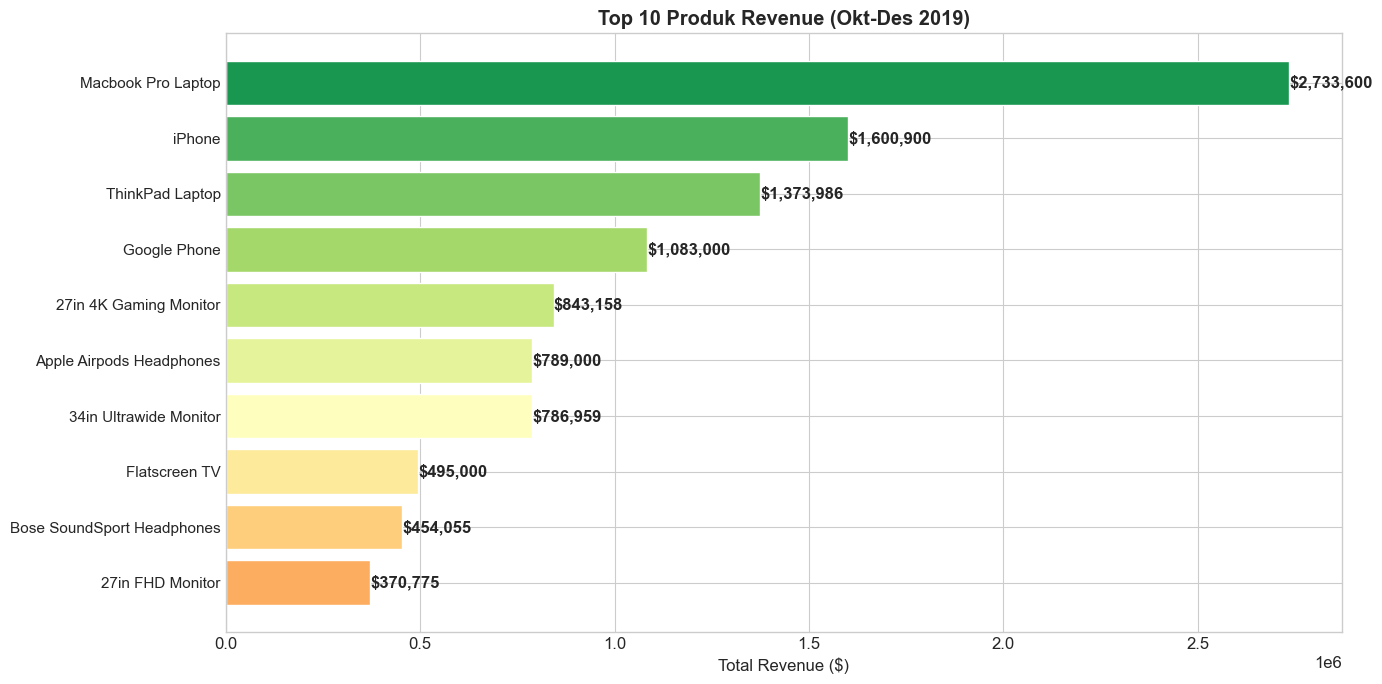

📊 Top 10 Produk Revenue (3 bulan terakhir):
    1. Macbook Pro Laptop                  $2,733,600.00
    2. iPhone                              $1,600,900.00
    3. ThinkPad Laptop                     $1,373,986.26
    4. Google Phone                        $1,083,000.00
    5. 27in 4K Gaming Monitor              $  843,158.38
    6. Apple Airpods Headphones            $  789,000.00
    7. 34in Ultrawide Monitor              $  786,959.29
    8. Flatscreen TV                       $  495,000.00
    9. Bose SoundSport Headphones          $  454,054.59
   10. 27in FHD Monitor                    $  370,775.28


In [14]:
# Top 10 produk revenue 3 bulan terakhir
last3 = df[df['Month'].isin([10,11,12])]
top10 = last3.groupby('Product')['Revenue'].sum().nlargest(10)

plt.figure(figsize=(14,7))
colors = plt.cm.RdYlGn(np.linspace(0.3,0.9,10))[::-1]
plt.barh(range(len(top10)), top10.values, color=colors, edgecolor='white')
plt.yticks(range(len(top10)), top10.index, fontsize=11)
plt.xlabel('Total Revenue ($)')
plt.title('Top 10 Produk Revenue (Okt-Des 2019)', fontweight='bold')
for i, v in enumerate(top10.values):
    plt.text(v+1000, i, f'${v:,.0f}', va='center', fontweight='bold')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

print("📊 Top 10 Produk Revenue (3 bulan terakhir):")
for i, (p, r) in enumerate(top10.items(), 1):
    print(f"   {i:2d}. {p:<35s} ${r:>12,.2f}")


Multi-product orders: 6,829 / 178,406 (3.8%)


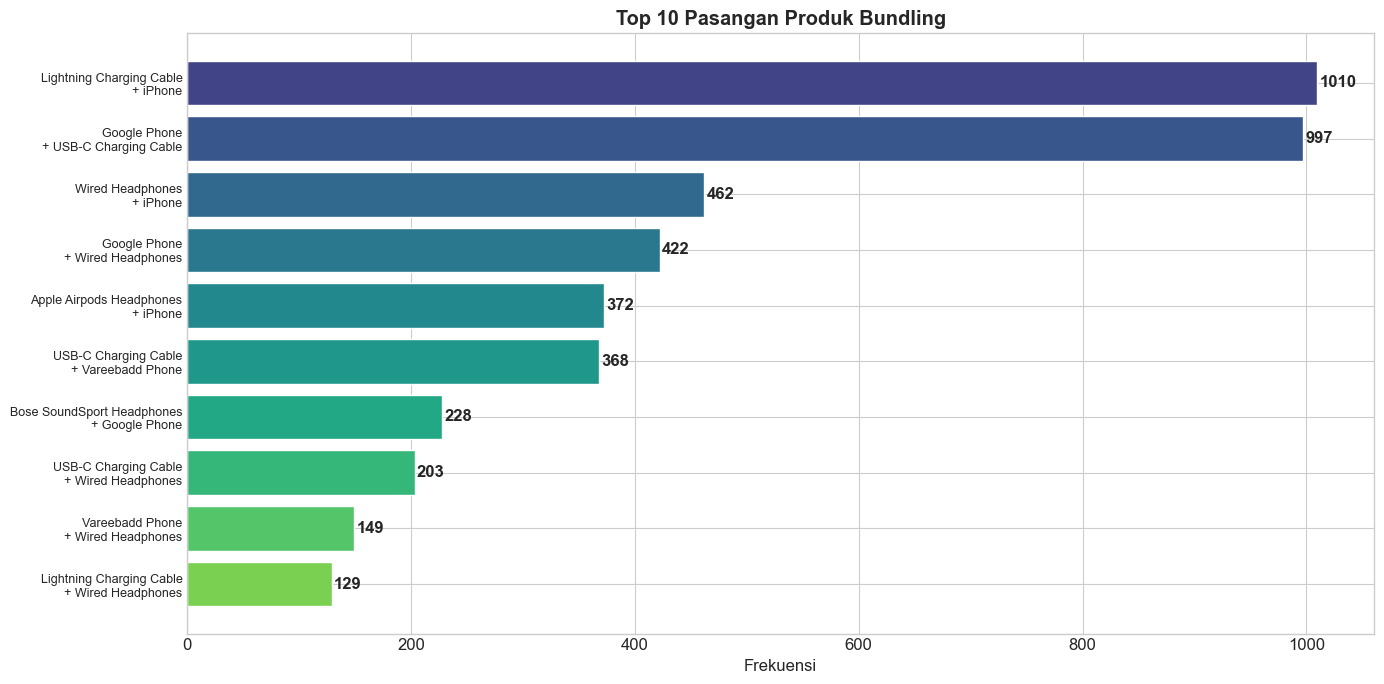


Rekomendasi Bundling (5 teratas):
   1. Lightning Charging Cable + iPhone (1010x)
   2. Google Phone + USB-C Charging Cable (997x)
   3. Wired Headphones + iPhone (462x)
   4. Google Phone + Wired Headphones (422x)
   5. Apple Airpods Headphones + iPhone (372x)


In [15]:
# Bundling Analysis
multi = df.groupby('Order ID').filter(lambda x: x['Product'].nunique() > 1)
print(f"Multi-product orders: {multi['Order ID'].nunique():,} / {df['Order ID'].nunique():,} ({multi['Order ID'].nunique()/df['Order ID'].nunique()*100:.1f}%)")

def get_pairs(g):
    return list(combinations(sorted(g['Product'].unique()), 2))

pairs = multi.groupby('Order ID').apply(get_pairs)
pair_counts = Counter([p for sub in pairs for p in sub])
top_pairs = pair_counts.most_common(10)

fig, ax = plt.subplots(figsize=(14,7))
labels = [f"{a}\n+ {b}" for (a,b), c in top_pairs]
vals = [c for _, c in top_pairs]
ax.barh(range(len(top_pairs)), vals, color=plt.cm.viridis(np.linspace(0.2,0.8,10)), edgecolor='white')
ax.set_yticks(range(len(top_pairs))); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Frekuensi'); ax.set_title('Top 10 Pasangan Produk Bundling', fontweight='bold')
for i, v in enumerate(vals): ax.text(v+2, i, str(v), va='center', fontweight='bold')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

print("\nRekomendasi Bundling (5 teratas):")
for i, ((a,b), c) in enumerate(top_pairs[:5], 1):
    print(f"   {i}. {a} + {b} ({c}x)")


### Q4: Top 5 Kota (Order & Spending)

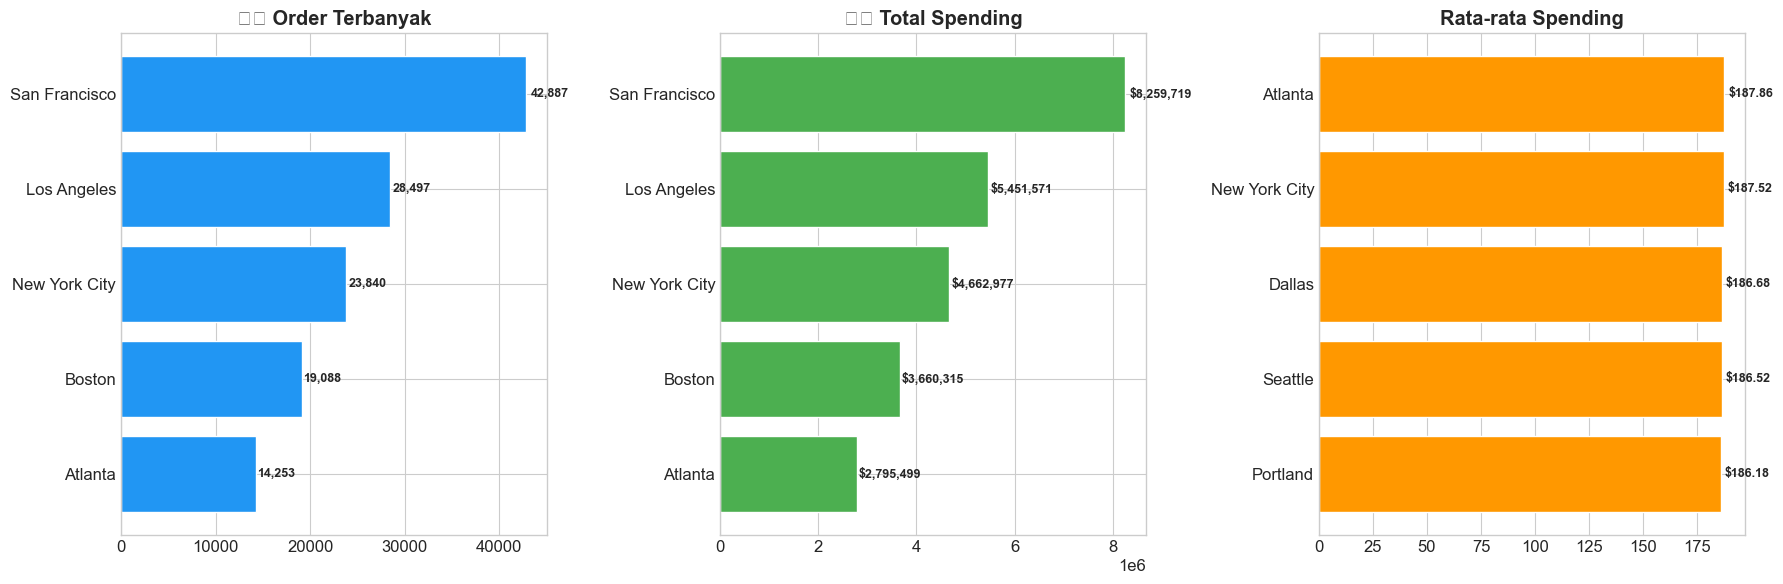

Insight: San Francisco & Los Angeles mendominasi order dan revenue.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, title, fmt, color) in zip(axes, [
    ('Order ID', 'Order Terbanyak', '{:,}', '#2196F3'),
    ('Revenue', 'Total Spending', '${:,.0f}', '#4CAF50'),
]):
    if col == 'Order ID':
        data = df.groupby('City')[col].nunique().nlargest(5)
    else:
        data = df.groupby('City')[col].sum().nlargest(5)
    ax.barh(data.index, data.values, color=color, edgecolor='white')
    ax.set_title(f'🏙️ {title}', fontweight='bold')
    for i, v in enumerate(data.values):
        ax.text(v*1.01, i, fmt.format(v), va='center', fontweight='bold', fontsize=9)
    ax.invert_yaxis()

data = df.groupby('City')['Revenue'].mean().nlargest(5)
axes[2].barh(data.index, data.values, color='#FF9800', edgecolor='white')
axes[2].set_title('Rata-rata Spending', fontweight='bold')
for i, v in enumerate(data.values):
    axes[2].text(v*1.01, i, f'${v:,.2f}', va='center', fontweight='bold', fontsize=9)
axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

print("Insight: San Francisco & Los Angeles mendominasi order dan revenue.")


### Q5: Analisis Rush Hour

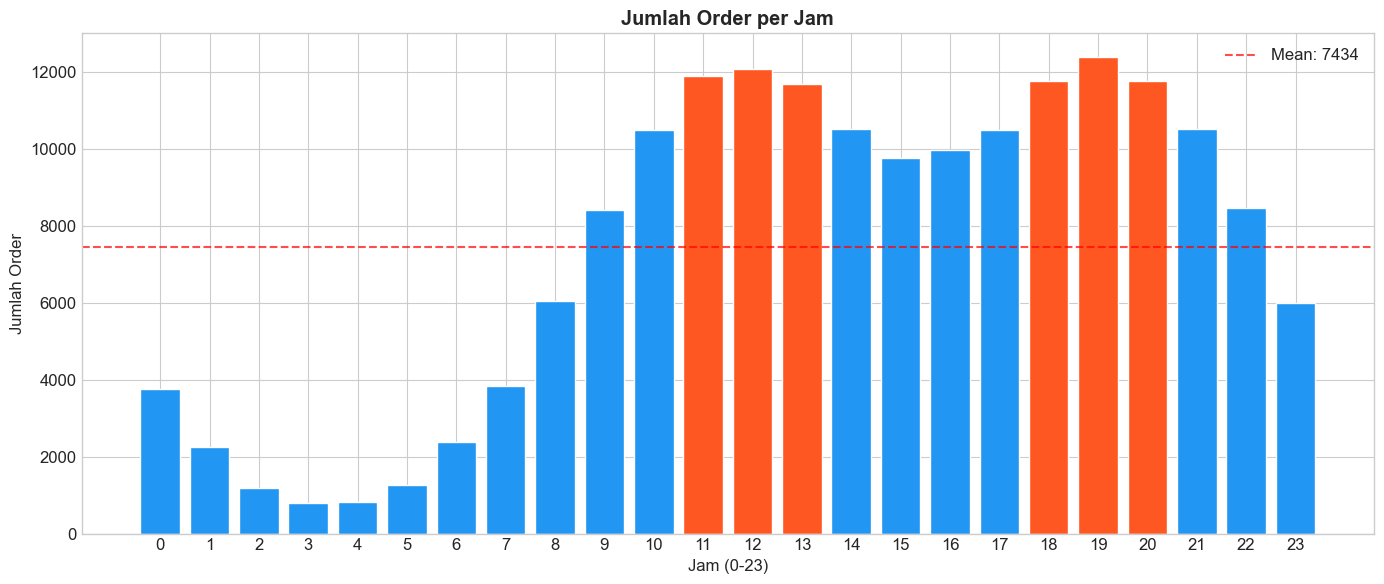

Peak Hour: 19:00 (12,377 order)
   Rush Hours: 11:00, 12:00, 13:00, 18:00, 19:00, 20:00
Dua puncak: siang (11-13) & sore-malam (18-20). Fokus kampanye pada jam ini.


In [17]:
hourly = df.groupby('Hour')['Order ID'].nunique()

plt.figure(figsize=(14, 6))
colors = ['#FF5722' if v >= hourly.quantile(0.75) else '#2196F3' for v in hourly.values]
plt.bar(hourly.index, hourly.values, color=colors, edgecolor='white')
plt.title('Jumlah Order per Jam', fontweight='bold')
plt.xlabel('Jam (0-23)'); plt.ylabel('Jumlah Order'); plt.xticks(range(24))
plt.axhline(y=hourly.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {hourly.mean():.0f}')
plt.legend(); plt.tight_layout(); plt.show()

rush = hourly[hourly >= hourly.quantile(0.75)].index.tolist()
print(f"Peak Hour: {hourly.idxmax()}:00 ({hourly.max():,} order)")
print(f"   Rush Hours: {', '.join(f'{h}:00' for h in sorted(rush))}")
print(f"Dua puncak: siang (11-13) & sore-malam (18-20). Fokus kampanye pada jam ini.")


---
## Tahap 4: Persiapan Data Time Series
Visitor = Purchase Address unik (proksi), Transaksi = Order ID unik.


Time Series: 2019-01-01 → 2019-12-31 (365 hari)
       Transactions    Visitors
count    365.000000  365.000000
mean     488.783562  488.421918
std      128.834227  128.634171
min      265.000000  265.000000
25%      391.000000  391.000000
50%      457.000000  457.000000
75%      575.000000  574.000000
max      843.000000  842.000000


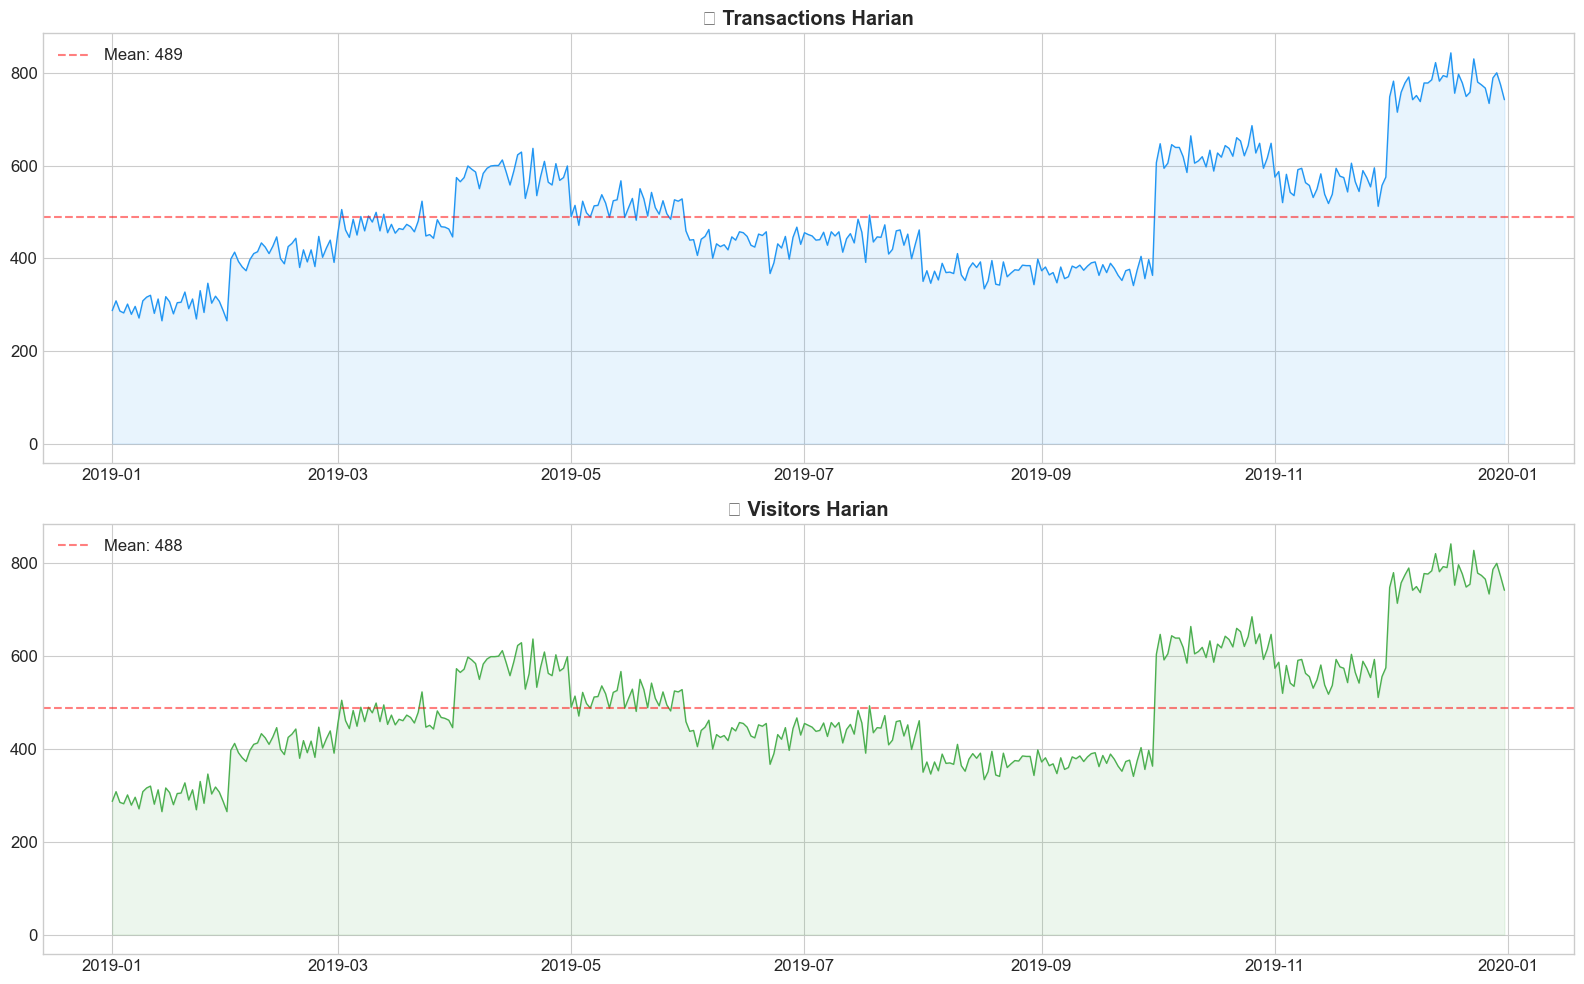

In [18]:
df_ts = df.set_index('Order Date').resample('D').agg(
    Transactions=('Order ID', 'nunique'),
    Visitors=('Purchase Address', 'nunique')
)
df_ts = df_ts.asfreq('D', fill_value=0)

print(f"Time Series: {df_ts.index.min().date()} → {df_ts.index.max().date()} ({len(df_ts)} hari)")
print(df_ts.describe())

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for i, (col, c) in enumerate([('Transactions','#2196F3'), ('Visitors','#4CAF50')]):
    axes[i].plot(df_ts.index, df_ts[col], color=c, linewidth=1)
    axes[i].fill_between(df_ts.index, df_ts[col], alpha=0.1, color=c)
    axes[i].set_title(f'📈 {col} Harian', fontweight='bold')
    axes[i].axhline(y=df_ts[col].mean(), color='red', linestyle='--', alpha=0.5, label=f"Mean: {df_ts[col].mean():.0f}")
    axes[i].legend()
plt.tight_layout(); plt.show()


---
## Tahap 5: Pemodelan Forecasting
3 Model: **Holt-Winters**, **SARIMA**, **LSTM**

**Data Split:** Train (Jan–Okt) | Validation (Nov) | Test (Des)


Train      : 2019-01-01 → 2019-10-31 (304 hari)
Validation : 2019-11-01 → 2019-11-30 (30 hari)
Test       : 2019-12-01 → 2019-12-31 (31 hari)


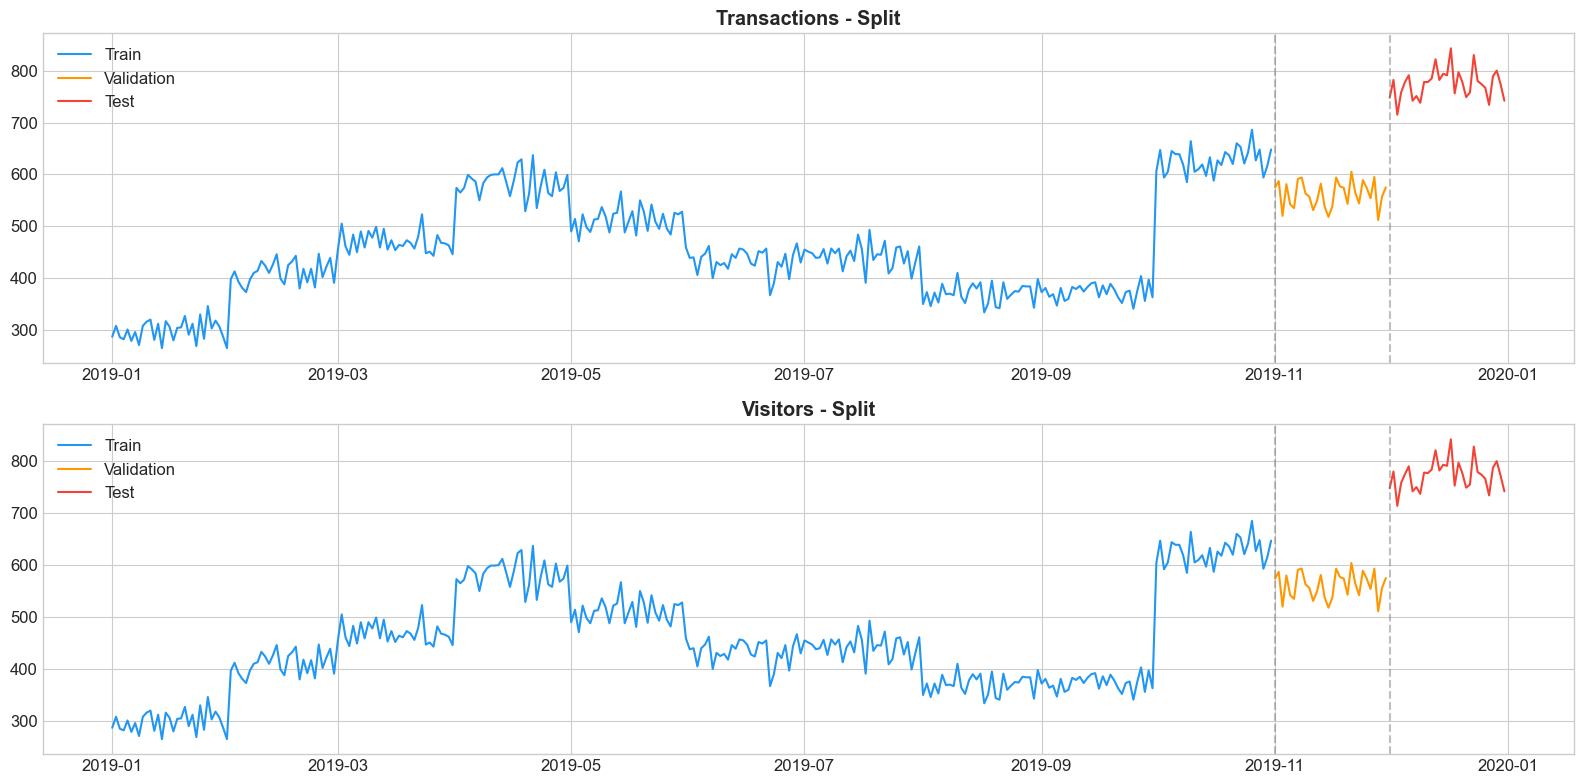

In [19]:
train = df_ts[:'2019-10-31']
val = df_ts['2019-11-01':'2019-11-30']
test = df_ts['2019-12-01':'2019-12-31']

print(f"Train      : {train.index.min().date()} → {train.index.max().date()} ({len(train)} hari)")
print(f"Validation : {val.index.min().date()} → {val.index.max().date()} ({len(val)} hari)")
print(f"Test       : {test.index.min().date()} → {test.index.max().date()} ({len(test)} hari)")

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
for i, t in enumerate(['Transactions', 'Visitors']):
    axes[i].plot(train.index, train[t], label='Train', color='#2196F3')
    axes[i].plot(val.index, val[t], label='Validation', color='#FF9800')
    axes[i].plot(test.index, test[t], label='Test', color='#F44336')
    axes[i].set_title(f'{t} - Split', fontweight='bold'); axes[i].legend()
    axes[i].axvline(x=pd.Timestamp('2019-11-01'), color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(x=pd.Timestamp('2019-12-01'), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


### Uji Stasioneritas & Diagnostik


📊 Transactions
ADF Test - Transactions (original): stat=-1.7033, p=0.4294 → Tidak Stasioner
ADF Test - Transactions (diff): stat=-13.6645, p=0.0000 → Stasioner


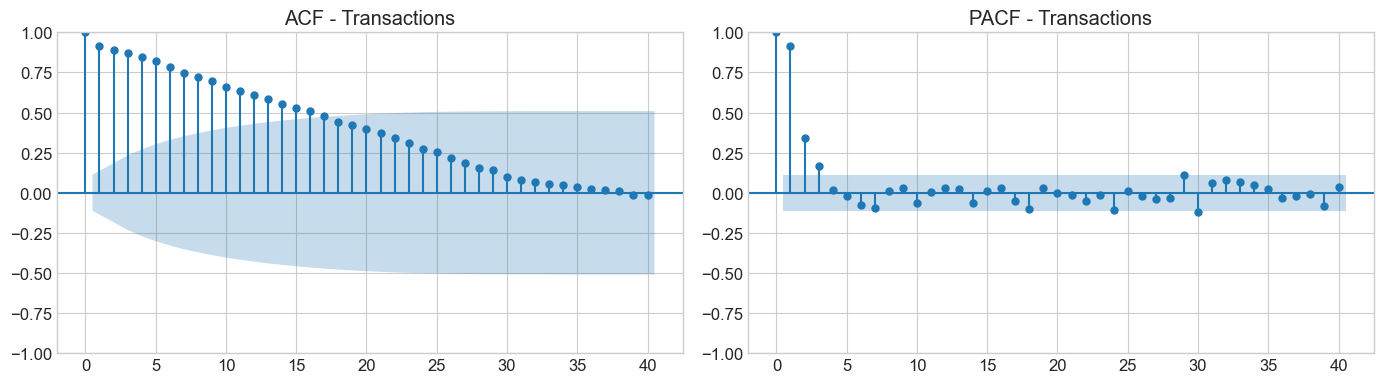


📊 Visitors
ADF Test - Visitors (original): stat=-1.7042, p=0.4289 → Tidak Stasioner
ADF Test - Visitors (diff): stat=-13.6672, p=0.0000 → Stasioner


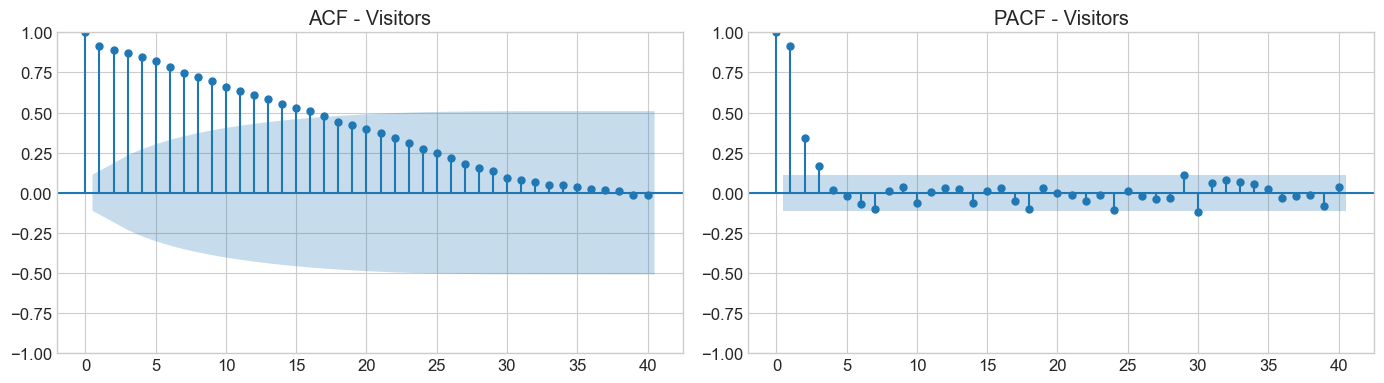

In [20]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f"ADF Test - {name}: stat={result[0]:.4f}, p={result[1]:.4f} → {'Stasioner' if result[1]<0.05 else 'Tidak Stasioner'}")
    return result[1] < 0.05

for target in ['Transactions', 'Visitors']:
    print(f"\n{'='*50}")
    print(f"📊 {target}")
    adf_test(train[target], f'{target} (original)')
    adf_test(train[target].diff().dropna(), f'{target} (diff)')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(train[target], lags=40, ax=axes[0], title=f'ACF - {target}')
    plot_pacf(train[target], lags=40, ax=axes[1], title=f'PACF - {target}')
    plt.tight_layout(); plt.show()


Berdasarkan Augmented Dickey-Fuller (ADF) Test, data original menunjukkan p-value > 0.05 (Non-Stationary). Namun, setelah dilakukan 1st order differencing, p-value menjadi 0.0000 (Stationary). Oleh karena itu, model SARIMA akan menggunakan parameter d=1 untuk memastikan model bekerja pada data yang sudah stasioner.

### Model 1: Holt Winters



Holt-Winters - Transactions
   MAE Validasi: 88.75


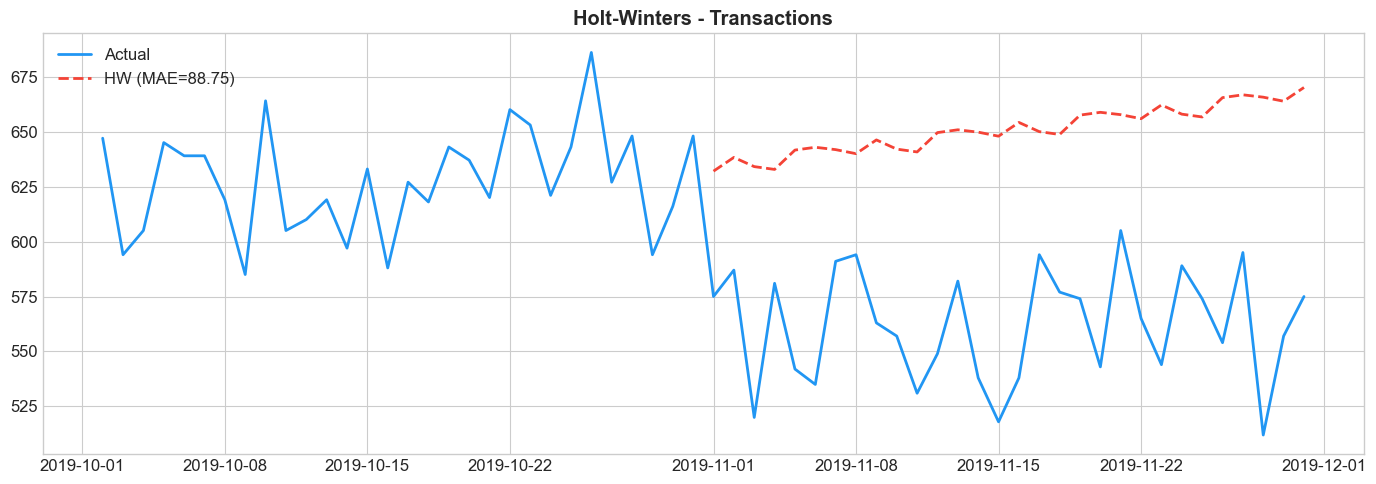


Holt-Winters - Visitors
   MAE Validasi: 88.28


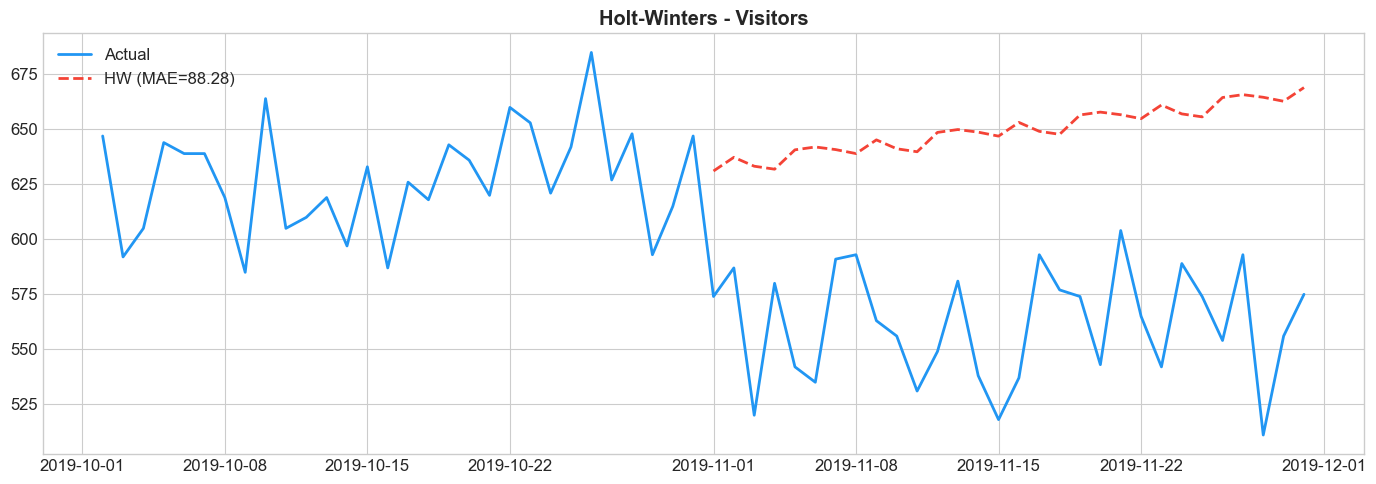

In [21]:
results_hw = {}
for target in ['Transactions', 'Visitors']:
    print(f"\n{'='*50}")
    print(f"Holt-Winters - {target}")
    
    hw = ExponentialSmoothing(train[target], seasonal_periods=7, trend='add', seasonal='add',
                              initialization_method='estimated').fit(optimized=True)
    hw_pred = hw.forecast(len(val))
    hw_mae = mean_absolute_error(val[target], hw_pred)
    results_hw[target] = {'model': hw, 'pred': hw_pred, 'mae': hw_mae}
    print(f"   MAE Validasi: {hw_mae:.2f}")
    
    plt.figure(figsize=(14, 5))
    historical = pd.concat([train[-30:], val])
    plt.plot(historical.index, historical[target], label='Actual', color='#2196F3', linewidth=2)
    plt.plot(val.index, hw_pred.values, label=f'HW (MAE={hw_mae:.2f})', color='#F44336', linestyle='--', linewidth=2)
    plt.title(f'Holt-Winters - {target}', fontweight='bold'); plt.legend(); plt.tight_layout(); plt.show()

    results_hw[target]['params'] = hw.params
    


Holt Winters gagal mengikuti pola aktual di periode validasi. Model memprediksi tren yang terus naik karena belajar dari pola Jan-Okt yang secara keseluruhan uptrend, padahal aktual November justru mengalami penurunan level. Selain itu, fluktuasi seasonalitas mingguan tidak tertangkap dengan baik, prediksi keluar sebagai garis yang terlalu smooth. Hal ini mengindikasikan nilai α yang terlalu kecil sehingga model tidak cukup responsif terhadap perubahan tren terbaru

### Model 2: SARIMA
Menggunakan seasonal ARIMA dengan seasonal_order (period=7 untuk pola mingguan).



SARIMA - Transactions
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  304
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 7)   Log Likelihood               -1505.090
Date:                           Tue, 07 Apr 2026   AIC                           3020.181
Time:                                   10:58:46   BIC                           3038.633
Sample:                               01-01-2019   HQIC                          3027.569
                                    - 10-31-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5141      0.034    -15.330      0.000      -0.580      -0.448
ar.L2         -0.282

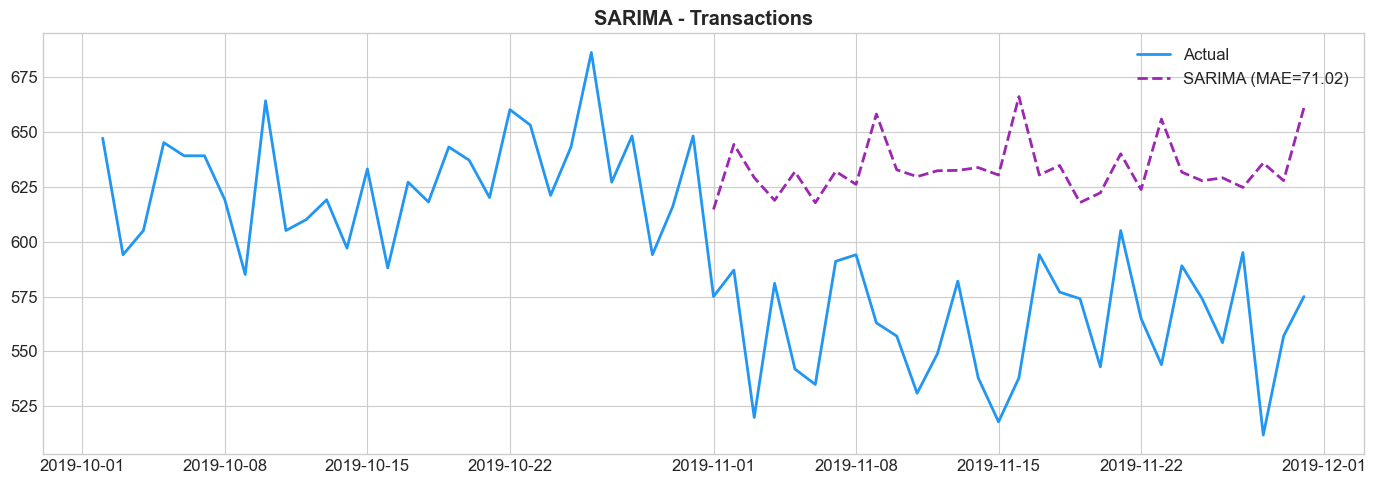


SARIMA - Visitors
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  304
Model:             SARIMAX(2, 1, 0)x(2, 1, 0, 7)   Log Likelihood               -1504.838
Date:                           Tue, 07 Apr 2026   AIC                           3019.676
Time:                                   10:58:52   BIC                           3038.128
Sample:                               01-01-2019   HQIC                          3027.064
                                    - 10-31-2019                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5162      0.034    -15.369      0.000      -0.582      -0.450
ar.L2         -0.2860   

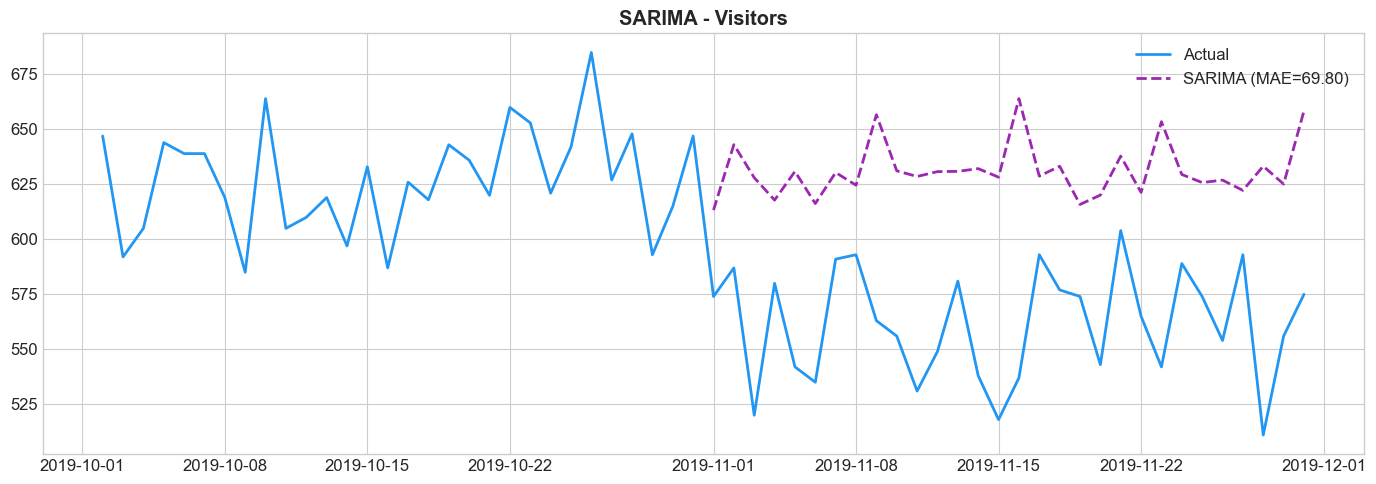

In [22]:
from pmdarima import auto_arima

results_sarima = {}
for target in ['Transactions', 'Visitors']:
    print(f"\n{'='*50}")
    print(f"SARIMA - {target}")
    
    # Auto-search parameter terbaik
    stepwise_fit = auto_arima(
        train[target],
        seasonal=True, m=7,       # pola mingguan
        d=1, D=1,                  # paksa differencing (data tidak stasioner)
        stepwise=True,             # lebih cepat dari exhaustive search
        information_criterion='aic',
        error_action='ignore',
        suppress_warnings=True
    )
    
    print(stepwise_fit.summary())
    best_order = stepwise_fit.order
    best_seasonal = stepwise_fit.seasonal_order
    print(f"   Best order: {best_order} x {best_seasonal}")
    
    # Refit pakai statsmodels ARIMA supaya konsisten dengan kode lainnya
    m = ARIMA(train[target], order=best_order, seasonal_order=best_seasonal).fit()
    pred = m.forecast(steps=len(val))
    pred.index = val.index
    mae = mean_absolute_error(val[target], pred)
    
    results_sarima[target] = {
        'model': m, 
        'cfg': (best_order, best_seasonal), 
        'pred': pred, 
        'mae': mae
    }
    print(f"   MAE Validasi: {mae:.2f}")
    
    plt.figure(figsize=(14, 5))
    historical = pd.concat([train[-30:], val])
    plt.plot(historical.index, historical[target], label='Actual', color='#2196F3', linewidth=2)
    plt.plot(val.index, pred.values, label=f'SARIMA (MAE={mae:.2f})', color='#9C27B0', linestyle='--', linewidth=2)
    plt.title(f'SARIMA - {target}', fontweight='bold'); plt.legend(); plt.tight_layout(); plt.show()

SARIMA berhasil menangkap pola seasonalitas mingguan dengan baik, namun kurang responsif terhadap level shift mendadak di awal November. LSTM yang pada akhirnya unggul karena kemampuannya menangkap pola non-linear yang tidak bisa dimodelkan secara eksplisit oleh model statistik tradisional


### Model 3: LSTM (Keras)




🔧 LSTM - Transactions
   Training (29345 params)...
   MAE Validasi: 28.12


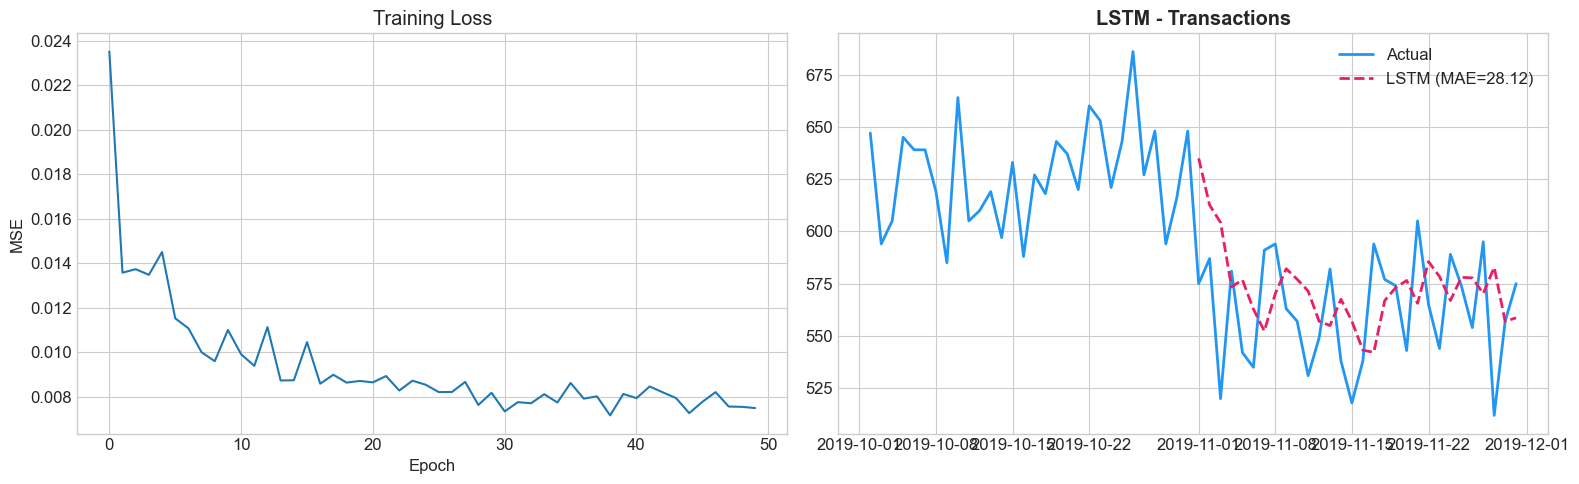


🔧 LSTM - Visitors
   Training (29345 params)...
   MAE Validasi: 25.63


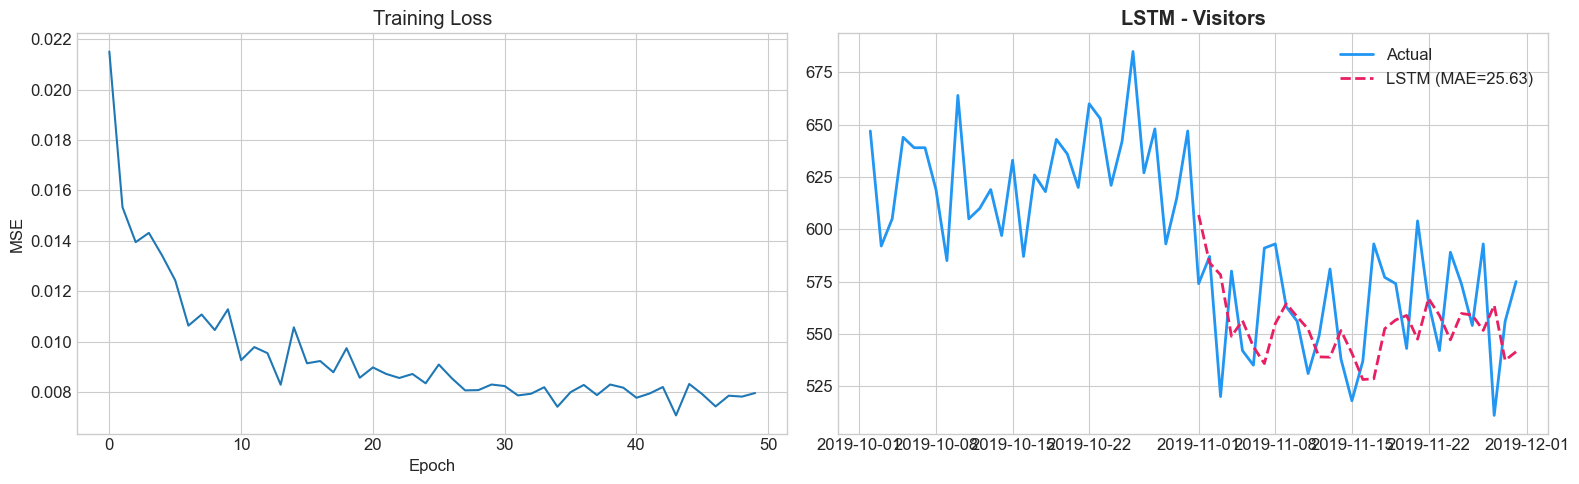

In [ ]:
results_lstm = {}
for target in ['Transactions', 'Visitors']:
    print(f"\n{'='*50}")
    print(f"🔧 LSTM - {target}")
    
    # Scale data
    scaler = MinMaxScaler()
    trainLSTM = train[target].values.reshape(-1, 1)
    testLSTM = val[target].values.reshape(-1, 1)
    
    scaler.fit(trainLSTM)
    scaled_train = scaler.transform(trainLSTM)
    scaled_test = scaler.transform(testLSTM)
    
    # TimeseriesGenerator
    n_input = 7
    n_features = 1
    generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
    
    # Model
    # model = Sequential()
    # model.add(LSTM(50, input_shape=(n_input, n_features)))
    # model.add(Dense(1))
    # model.compile(optimizer='adam', loss='mse')

    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(n_input, n_features)))
    model.add(Dropout(0.2)) # Biar gak overfit
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    print(f"   Training ({model.count_params()} params)...")
    history = model.fit(generator, epochs=50, verbose=0)
    
    # Predict
    # testPredict = model.predict(scaled_test, verbose=0)
    # testPredict = scaler.inverse_transform(testPredict.reshape(-1, 1)).flatten()

    combined = np.concatenate([scaled_train[-7:], scaled_test])

    val_gen = TimeseriesGenerator(combined, combined, length=n_input, batch_size=1)
    testPredict = model.predict(val_gen, verbose=0)
    testPredict = scaler.inverse_transform(testPredict.reshape(-1, 1)).flatten()
    
    lstm_mae = mean_absolute_error(val[target], testPredict)
    results_lstm[target] = {'model': model, 'scaler': scaler, 'pred': testPredict, 'mae': lstm_mae, 'history': history}
    print(f"   MAE Validasi: {lstm_mae:.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(history.history['loss']); axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
    historical = pd.concat([train[-30:], val])
    axes[1].plot(historical.index, historical[target], label='Actual', color='#2196F3', linewidth=2)
    axes[1].plot(val.index, testPredict, label=f'LSTM (MAE={lstm_mae:.2f})', color='#E91E63', linestyle='--', linewidth=2)
    axes[1].set_title(f'LSTM - {target}', fontweight='bold'); axes[1].legend()
    plt.tight_layout(); plt.show()


LSTM menunjukkan performa terbaik dengan MAE 28.12 (Transactions) dan 25.63 (Visitors). Training loss konvergen dengan baik tanpa indikasi overfitting. Model berhasil menangkap level shift mendadak di awal November yang gagal ditangkap oleh HW maupun SARIMA, serta mampu mengikuti fluktuasi seasonalitas harian dengan lebih akurat. Keunggulan ini berasal dari kemampuan LSTM dalam memodelkan dependensi temporal non-linear yang kompleks.

Secara keseluruhan model cukup kesulitan karena pola data memang memiliki beberap stage yg berbeda seeperti di awal bulan yang cenderung rendah lalu mulai naik dan dipertengahan mulai turun lagi, lalu di akhir periode tiba-tiba naik drastis. Ini yg menyebabkan model keseulitan membaca pola/trennya

---
## Tahap 6: Evaluasi dan Interpretasi
Metrik: **MAE** (utama), RMSE, MAPE, R²


PERBANDINGAN MODEL - VALIDASI (NOVEMBER 2019)
      Target        Model       MAE      RMSE      MAPE         R²
Transactions Holt-Winters 88.754838 92.843456 16.030537 -12.459515
Transactions       SARIMA 71.019143 76.722522 12.876845  -8.191207
Transactions         LSTM 28.115011 34.210244  5.067952  -0.827423
    Visitors Holt-Winters 88.278379 92.361449 15.957137 -12.459864
    Visitors       SARIMA 69.801771 75.549086 12.668578  -8.005703
    Visitors         LSTM 25.633954 31.673523  4.534585  -0.582894


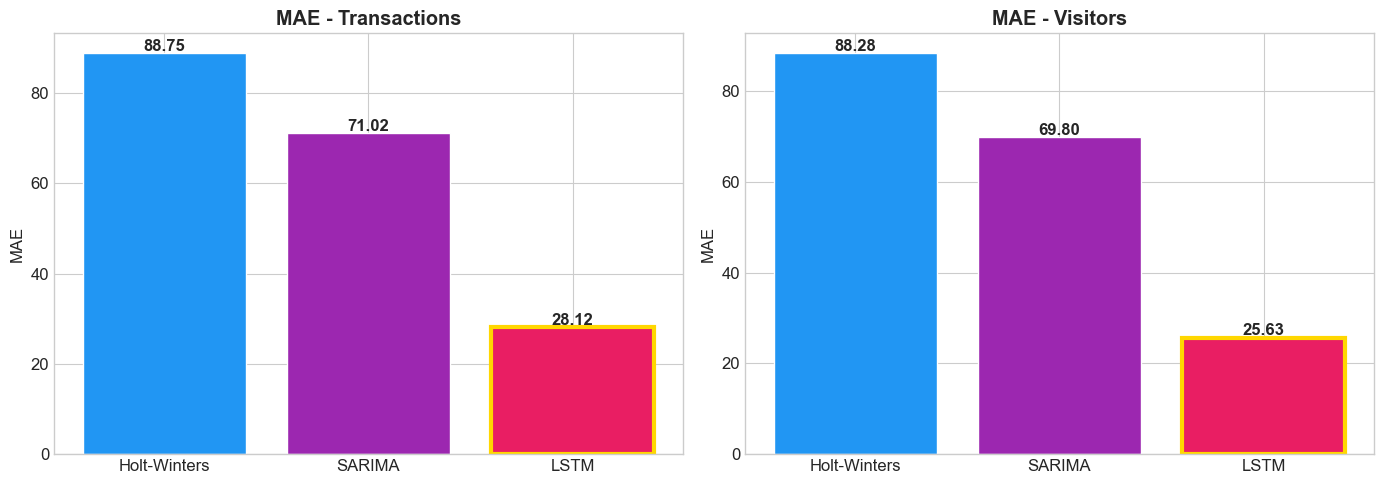


Transactions: Model terbaik = LSTM (MAE=28.12)

Visitors: Model terbaik = LSTM (MAE=25.63)


In [25]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("="*70)
print("PERBANDINGAN MODEL - VALIDASI (NOVEMBER 2019)")
print("="*70)

comparison = []
for target in ['Transactions', 'Visitors']:
    for name, res in [('Holt-Winters', results_hw), ('SARIMA', results_sarima), ('LSTM', results_lstm)]:
        actual = val[target].values
        pred = res[target]['pred'] if isinstance(res[target]['pred'], np.ndarray) else res[target]['pred'].values
        
        row = {
            'Target': target, 'Model': name,
            'MAE': mean_absolute_error(actual, pred),
            'RMSE': np.sqrt(mean_squared_error(actual, pred)),
            'MAPE': mape(actual, pred),
            'R²': r2_score(actual, pred)
        }
        comparison.append(row)

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))

# Bar chart MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(['Transactions', 'Visitors']):
    sub = df_comp[df_comp['Target']==target]
    colors = ['#2196F3', '#9C27B0', '#E91E63']
    bars = axes[i].bar(sub['Model'], sub['MAE'], color=colors, edgecolor='white')
    best_idx = sub['MAE'].values.argmin()
    bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(3)
    axes[i].set_title(f'MAE - {target}', fontweight='bold'); axes[i].set_ylabel('MAE')
    for j, v in enumerate(sub['MAE']): axes[i].text(j, v+0.5, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

# Identifikasi model terbaik
for target in ['Transactions', 'Visitors']:
    sub = df_comp[df_comp['Target']==target]
    best = sub.loc[sub['MAE'].idxmin()]
    print(f"\n{target}: Model terbaik = {best['Model']} (MAE={best['MAE']:.2f})")


### Evaluasi pada Data Test (Desember 2019)

In [26]:
print("="*70)
print("EVALUASI LSTM - TEST (DESEMBER 2019)")
print("="*70)
test_results = {}

for target in ['Transactions', 'Visitors']:
    saved_model = results_lstm[target]['model']
    saved_scaler = results_lstm[target]['scaler']
    
    # Predict test pakai model yang sudah ditraining
    scaled_train = saved_scaler.transform(train[target].values.reshape(-1, 1))
    scaled_val   = saved_scaler.transform(val[target].values.reshape(-1, 1))
    scaled_test  = saved_scaler.transform(test[target].values.reshape(-1, 1))
    
    # Butuh 7 hari terakhir val sebagai window untuk prediksi test
    combined = np.concatenate([scaled_train[-7:], scaled_val, scaled_test])
    # window dimulai dari posisi yang menghasilkan prediksi bulan test
    test_combined = np.concatenate([scaled_val[-7:], scaled_test])
    test_gen = TimeseriesGenerator(test_combined, test_combined, length=7, batch_size=1)
    
    pred = saved_model.predict(test_gen, verbose=0)
    pred = saved_scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    
    test_mae  = mean_absolute_error(test[target], pred)
    test_rmse = np.sqrt(mean_squared_error(test[target], pred))
    test_r2   = r2_score(test[target], pred)
    
    test_results[target] = {'model': 'LSTM', 'pred': pred, 'mae': test_mae}
    
    print(f"\n  {target}:")
    print(f"    MAE Test : {test_mae:.2f}")
    print(f"    RMSE Test: {test_rmse:.2f}")
    print(f"    R² Test  : {test_r2:.4f}")

EVALUASI LSTM - TEST (DESEMBER 2019)

  Transactions:
    MAE Test : 34.14
    RMSE Test: 50.73
    R² Test  : -2.3111

  Visitors:
    MAE Test : 65.02
    RMSE Test: 76.10
    R² Test  : -6.5119


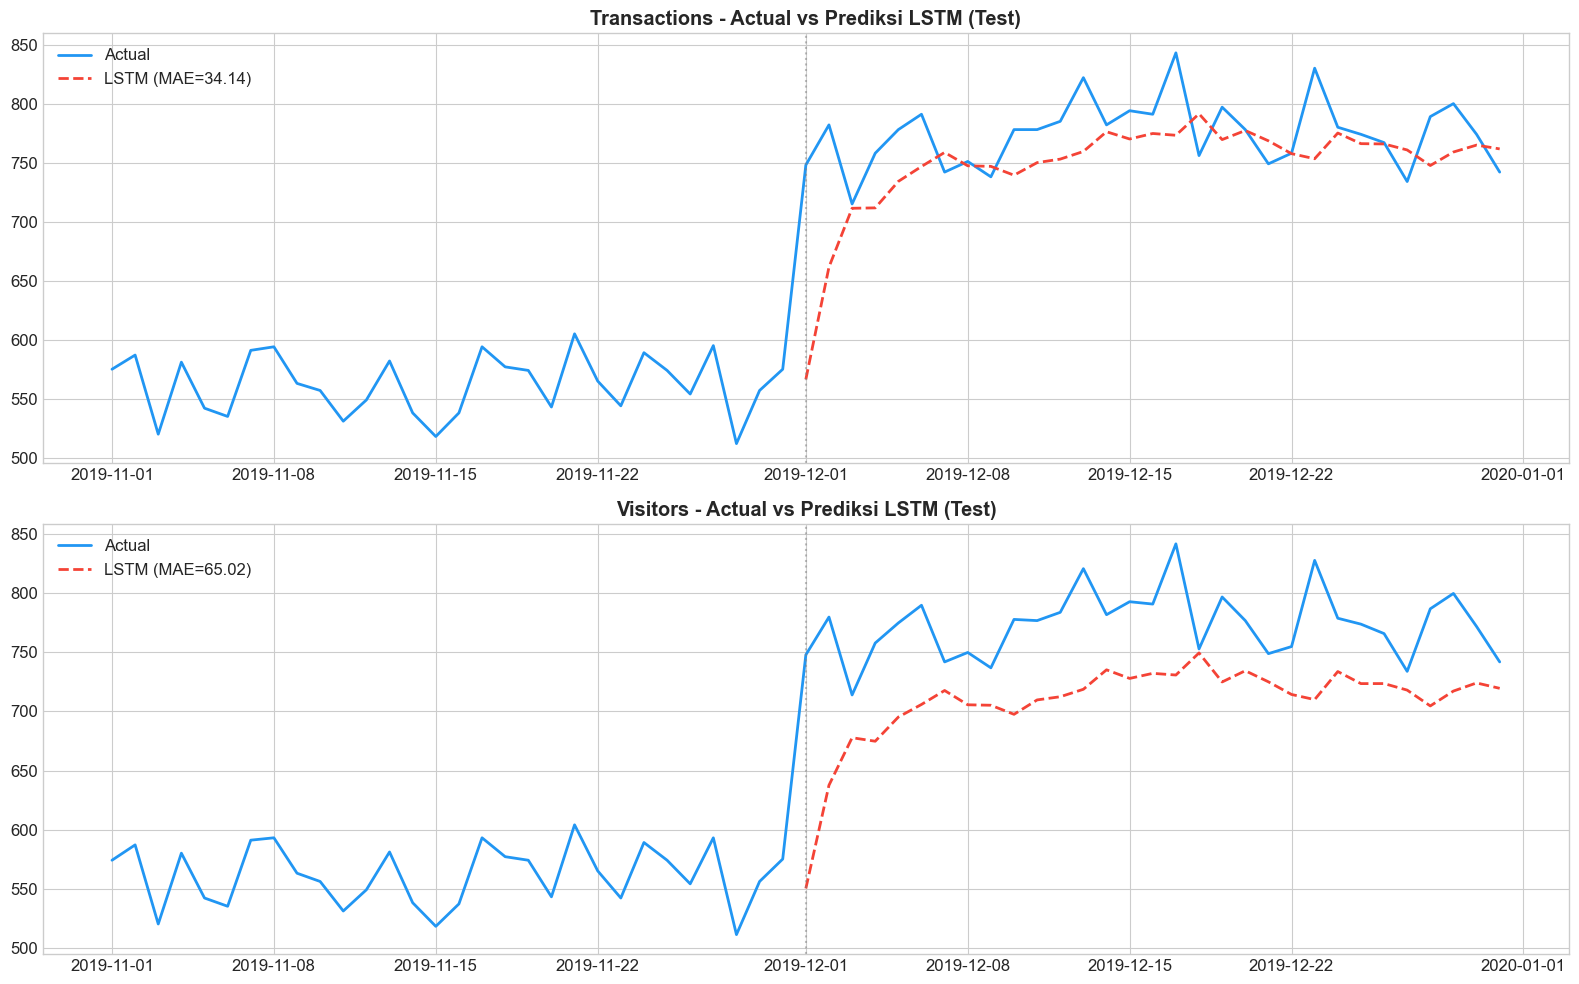

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for i, target in enumerate(['Transactions', 'Visitors']):
    pred = test_results[target]['pred']
    mae  = test_results[target]['mae']
    
    # Hanya tampilkan 30 hari sebelum test + test
    historical = pd.concat([val[-30:], test])
    axes[i].plot(historical.index, historical[target], label='Actual', color='#2196F3', linewidth=2)
    axes[i].plot(test.index, pred, label=f'LSTM (MAE={mae:.2f})', color='#F44336', linestyle='--', linewidth=2)
    axes[i].set_title(f'{target} - Actual vs Prediksi LSTM (Test)', fontweight='bold')
    axes[i].legend(loc='upper left')
    axes[i].axvline(x=pd.Timestamp('2019-12-01'), color='gray', linestyle=':', alpha=0.5)
plt.tight_layout(); plt.show()

### Forecasting 30 Hari ke Depan

FORECASTING 30 HARI KE DEPAN (JANUARI 2020)

Transactions (LSTM):
   Avg harian : 712
   Total 30hr : 21370
   Min-Max    : 690 - 751

Visitors (LSTM):
   Avg harian : 570
   Total 30hr : 17101
   Min-Max    : 507 - 709


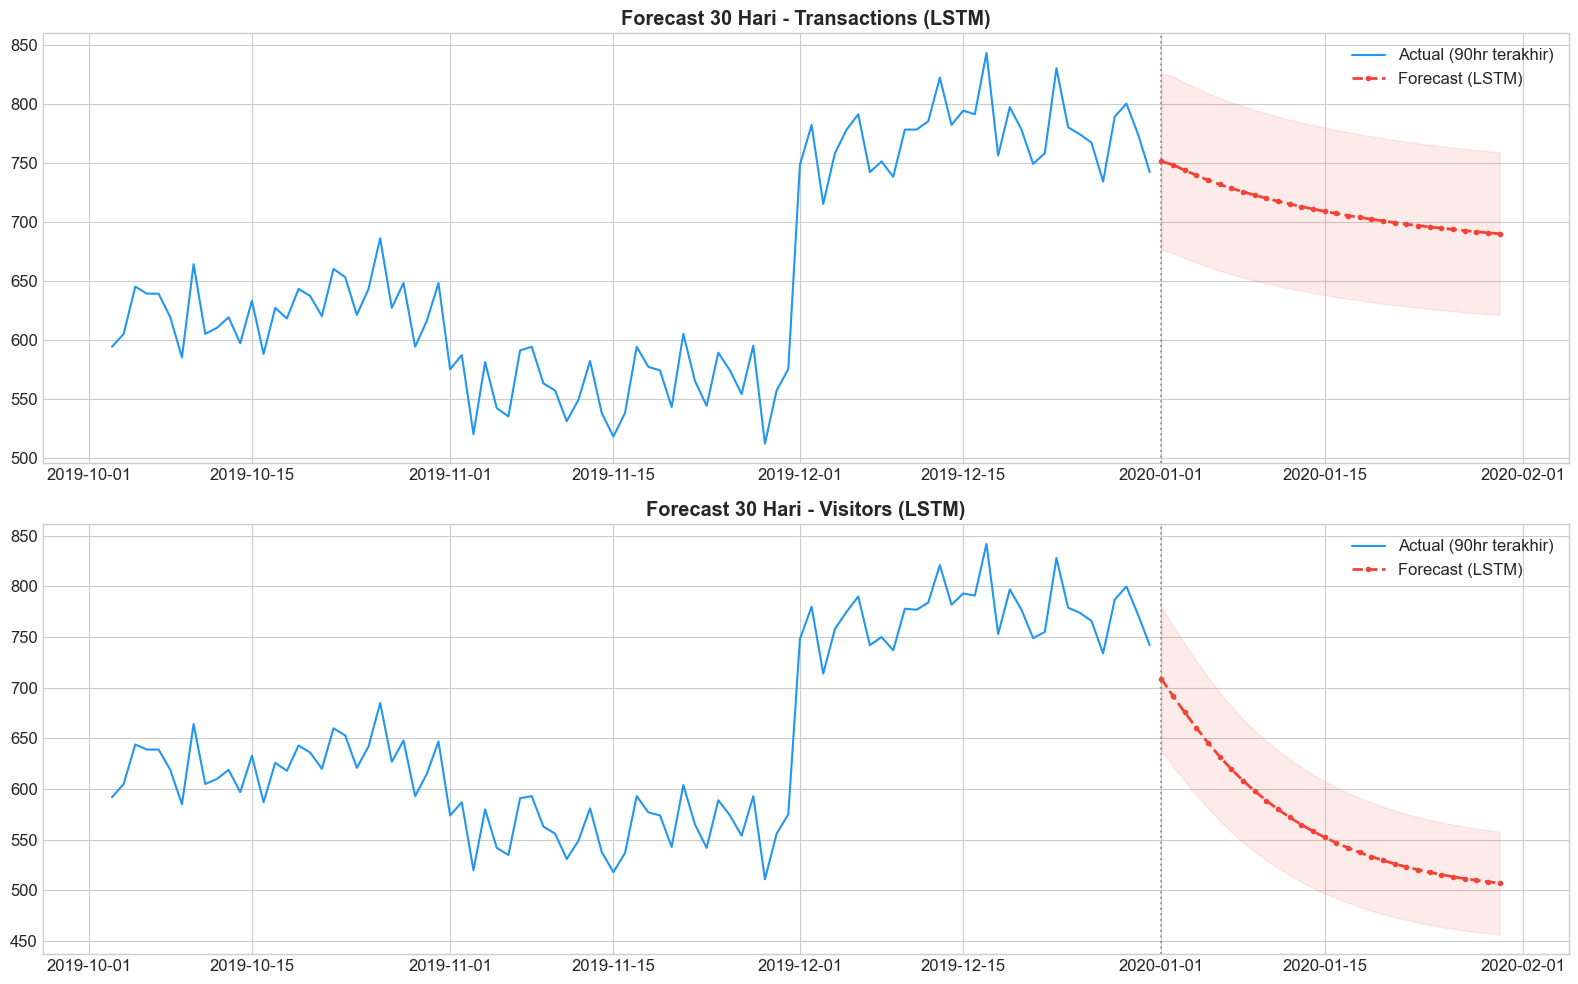

In [28]:
print("="*70)
print("FORECASTING 30 HARI KE DEPAN (JANUARI 2020)")
print("="*70)

future_dates = pd.date_range('2020-01-01', periods=30, freq='D')
forecasts = {}

for target in ['Transactions', 'Visitors']:
    saved_scaler = results_lstm[target]['scaler']
    saved_model  = results_lstm[target]['model']
    
    all_data   = df_ts[target].values.reshape(-1, 1)
    scaled_all = saved_scaler.transform(all_data)
    
    # Iterative forecast
    current = scaled_all[-7:].flatten().tolist()
    preds = []
    for _ in range(30):
        x = np.array(current[-7:]).reshape(1, 7, 1)
        p = saved_model.predict(x, verbose=0)[0][0]
        preds.append(p)
        current.append(p)
    
    fc = saved_scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    fc = pd.Series(fc, index=future_dates)
    forecasts[target] = fc
    
    print(f"\n{target} (LSTM):")
    print(f"   Avg harian : {np.mean(fc):.0f}")
    print(f"   Total 30hr : {np.sum(fc):.0f}")
    print(f"   Min-Max    : {np.min(fc):.0f} - {np.max(fc):.0f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for i, target in enumerate(['Transactions', 'Visitors']):
    fc = forecasts[target]
    axes[i].plot(df_ts.index[-90:], df_ts[target][-90:], label='Actual (90hr terakhir)', color='#2196F3', linewidth=1.5)
    axes[i].plot(future_dates, fc, label='Forecast (LSTM)', color='#F44336', linestyle='--', linewidth=2, marker='o', markersize=3)
    axes[i].fill_between(future_dates, np.array(fc)*0.9, np.array(fc)*1.1, alpha=0.1, color='#F44336')
    axes[i].axvline(x=pd.Timestamp('2020-01-01'), color='gray', linestyle=':', alpha=0.7)
    axes[i].set_title(f'Forecast 30 Hari - {target} (LSTM)', fontweight='bold')
    axes[i].legend()
plt.tight_layout(); plt.show()

Kalo kita lihat tren penjualan menurun di awal bulan karen meang di awal bulan tahun 2019 juga rendah penjualannya namun model lstm sepertinya tidak begitu menangkap polanya karena dia melakukan input dari data dia sendiri dari hari sebelumnya. Dari hasil riset saya ini merupakan konsekuensi dari metode iterative forecasting, setiap prediksi hari berikutnya menggunakan output prediksi hari sebelumnya sebagai input, sehingga error terakumulasi dan model kehilangan kemampuan menangkap pola naik-turun jangka pendek. Untuk kebutuhan bisnis, angka forecast ini sebaiknya dijadikan sebagai estimasi level rata-rata, bukan prediksi harian yang presisi.




Mesikpun LSTM berdasarkan data validation dan test adalah hasil terbaik, sayangnya untuk forcast 30 hari LSTM tidak memberikan hasil yang memuaskan. Untuk itu saya mencoba forecast menggunakan model lain yang kedua terbaik, yaitu SARIMA


Transactions (SARIMA):
   Avg harian : 725
   Total 30hr : 21737
   Min-Max    : 681 - 766

Visitors (SARIMA):
   Avg harian : 724
   Total 30hr : 21727
   Min-Max    : 681 - 765


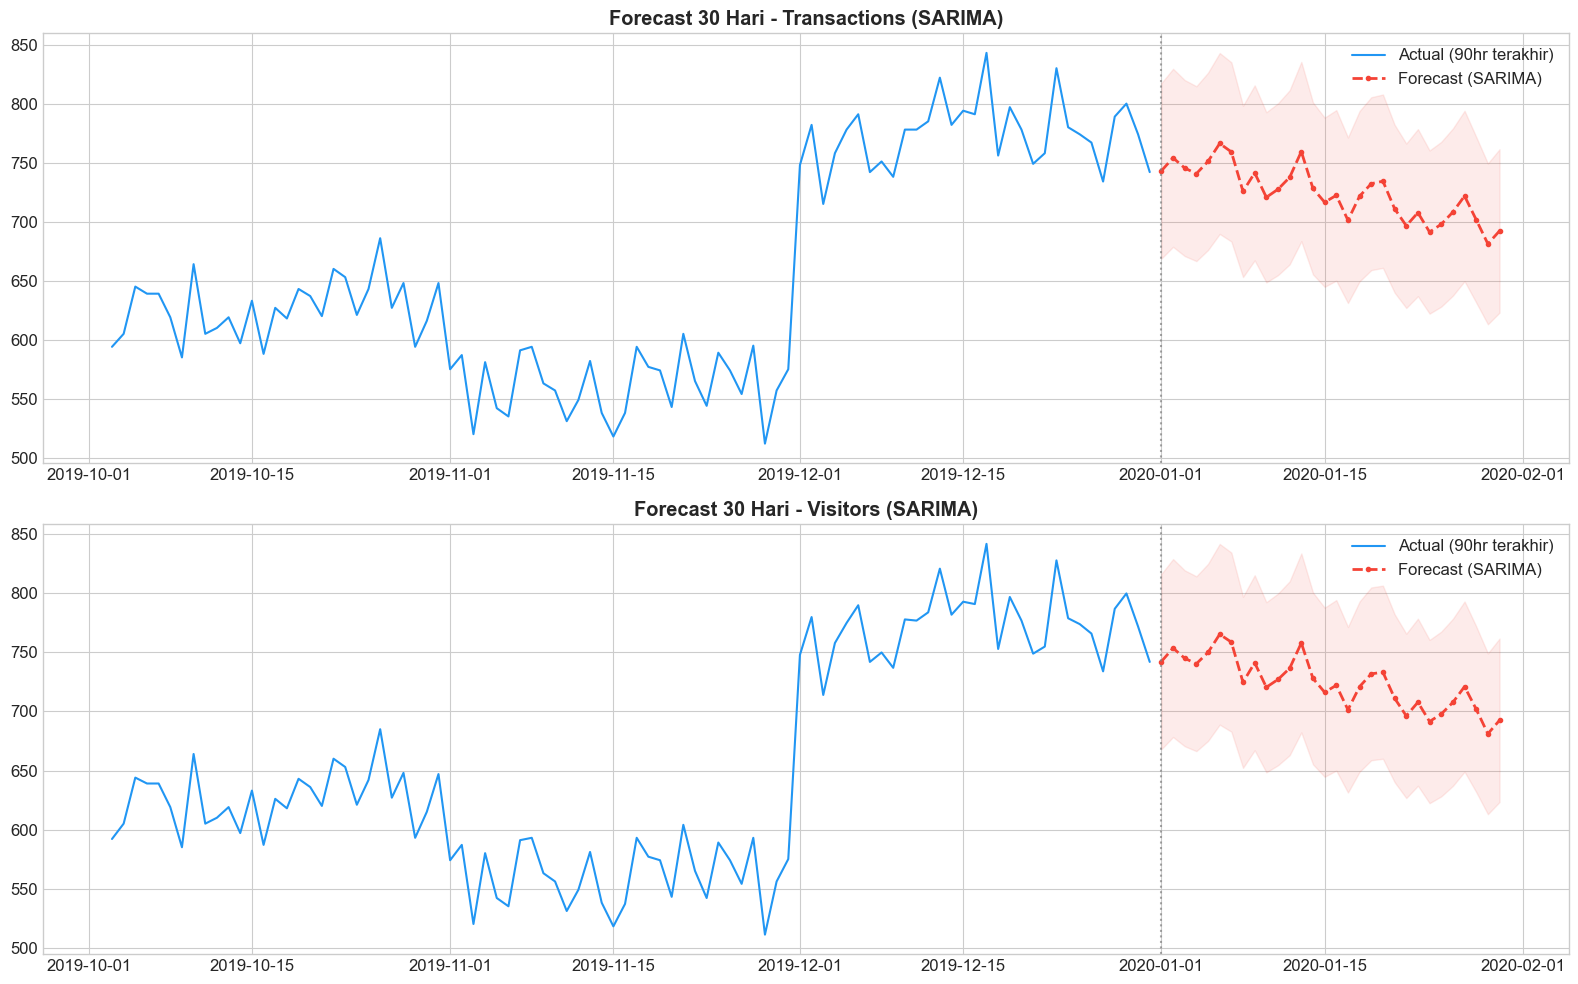

In [29]:
for target in ['Transactions', 'Visitors']:
    cfg = results_sarima[target]['cfg']
    m = ARIMA(df_ts[target], order=cfg[0], seasonal_order=cfg[1]).fit()
    fc = m.forecast(30)
    fc.index = future_dates
    forecasts[target] = fc

    print(f"\n{target} (SARIMA):")
    print(f"   Avg harian : {np.mean(fc):.0f}")
    print(f"   Total 30hr : {np.sum(fc):.0f}")
    print(f"   Min-Max    : {np.min(fc):.0f} - {np.max(fc):.0f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for i, target in enumerate(['Transactions', 'Visitors']):
    fc = forecasts[target]
    axes[i].plot(df_ts.index[-90:], df_ts[target][-90:], label='Actual (90hr terakhir)', color='#2196F3', linewidth=1.5)
    axes[i].plot(future_dates, fc, label='Forecast (SARIMA)', color='#F44336', linestyle='--', linewidth=2, marker='o', markersize=3)
    axes[i].fill_between(future_dates, np.array(fc)*0.9, np.array(fc)*1.1, alpha=0.1, color='#F44336')
    axes[i].axvline(x=pd.Timestamp('2020-01-01'), color='gray', linestyle=':', alpha=0.7)
    axes[i].set_title(f'Forecast 30 Hari - {target} (SARIMA)', fontweight='bold')
    axes[i].legend()
plt.tight_layout(); plt.show()

Kalo kita lihat sama seperti sebelumnya, terjadi pola/tren yang menurun karena awal bulan. Namun, dibanding LSTM, SARIMA menghasilkan forecast yang lebih realistis untuk long-horizon karena mampu mempertahankan pola seasonalitas mingguan (naik-turun setiap 7 hari) tanpa mengalami drift yang terlalu ekstrem

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185916 entries, 0 to 185915
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185916 non-null  int64         
 1   Product           185916 non-null  object        
 2   Quantity Ordered  185916 non-null  int64         
 3   Price Each        185916 non-null  float64       
 4   Order Date        185916 non-null  datetime64[ns]
 5   Purchase Address  185916 non-null  object        
 6   City              185916 non-null  object        
 7   PostalCode        185916 non-null  int64         
 8   Revenue           185916 non-null  float64       
 9   Hour              185916 non-null  int32         
 10  Day               185916 non-null  int32         
 11  Month             185916 non-null  int32         
 12  Month_Name        185916 non-null  object        
 13  Day_Name          185916 non-null  object        
 14  Week     

In [31]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City,PostalCode,Revenue,Hour,Day,Month,Month_Name,Day_Name,Week,Date
0,147268,Wired Headphones,1,11.99,2019-01-01 03:07:00,"9 Lake St, New York City, NY 10001",New York City,10001,11.99,3,1,1,January,Tuesday,1,2019-01-01
1,148041,USB-C Charging Cable,1,11.95,2019-01-01 03:40:00,"760 Church St, San Francisco, CA 94016",San Francisco,94016,11.95,3,1,1,January,Tuesday,1,2019-01-01
2,149343,Apple Airpods Headphones,1,150.00,2019-01-01 04:56:00,"735 5th St, New York City, NY 10001",New York City,10001,150.00,4,1,1,January,Tuesday,1,2019-01-01
3,149964,AAA Batteries (4-pack),1,2.99,2019-01-01 05:53:00,"75 Jackson St, Dallas, TX 75001",Dallas,75001,2.99,5,1,1,January,Tuesday,1,2019-01-01
4,149350,USB-C Charging Cable,2,11.95,2019-01-01 06:03:00,"943 2nd St, Atlanta, GA 30301",Atlanta,30301,23.90,6,1,1,January,Tuesday,1,2019-01-01


Viewed task.md:1-127

Berikut adalah versi yang sudah disesuaikan agar tidak menggunakan huruf kapital semua, dengan sedikit perbaikan tata bahasa agar lebih enak dibaca:

### Ringkasan Analisis

**Temuan Utama:**

1. **Statistik Penjualan 2019:**
   - Total Revenue: $34,483,365.68
   - Total Order: 178,406
   - Total Barang Terjual: 209,038
   - Rata-rata barang/transaksi: 1.17
   - Rata-rata spending/transaksi: $193.29

2. **Tren:** Peningkatan signifikan di Q4 (*holiday season*). Pola musiman mingguan teramati.

3. **Produk:** *Top* produk berdasarkan *revenue* didominasi oleh elektronik premium. Peluang *bundling* teridentifikasi pada pasangan produk yang populer.

4. **Geografis:** San Francisco & Los Angeles mendominasi order dan *revenue*.

5. **Rush Hour:** Puncak penjualan terjadi pada jam 11:00-13:00 dan 18:00-20:00.

6. **Forecasting:** Secara nilai MAE, LSTM adalah model yang terbaik. Namun, dalam membaca pola time series, model SARIMA menunjukkan performa yang lebih baik dibandingkan LSTM dalam memprediksi (forecasting) 30 hari ke depan.

**Rekomendasi Strategis:**

1. **Marketing:** Fokuskan kampanye pemasaran pada *rush hour* (11:00-13:00 & 18:00-20:00). Kirimkan *push notification* menjelang jam-jam sibuk tersebut.

2. **Bundling:** Tawarkan paket *bundling* untuk produk-produk yang sering dibeli secara bersamaan, berikan diskon khusus untuk meningkatkan *average order value* (nilai rata-rata pesanan).

3. **Geografis:** Tingkatkan investasi pemasaran di kota-kota *top performer*. Replikasi strategi yang berhasil di kota-kota tersebut ke wilayah lainnya.

4. **Seasonal:** Persiapkan stok barang dan kapasitas ekstra menjelang kuartal keempat (Q4). Anggaran untuk *marketing* di Q4 juga perlu dialokasikan lebih besar.

5. **Operasional:** Berdasarkan hasil forecasting dan hubungannya dengan tren musiman (*seasonal*), persiapkan kapasitas operasional yang memadai. Lakukan monitoring secara berkala antara realisasi penjualan dengan prediksi model. 


### Reflection Question

1. Mengapa penting menganalisis tren waktu (trend & seasonality) sebelum membuat model forecasting, dan bagaimana pengabaian pola musiman bisa memengaruhi keputusan bisnis? Jelaskan dengan contoh bagaimana prediksi yang mengabaikan seasonality dapat menyebabkan salah perencanaan stok atau kampanye pemasaran.

Mengabaikan seasonality adalah langkah yg salah karena dengan kita menganalisis trend dan seasonality kita bisa tahu kapan kita bisa menyiapkan stok atau kampanye yang tepat, seperti contoh data ini bahwa terdapat trend pada libur akhir tahun yang melonjak, dengan informasi ini kita bisa menyiapkan strategi untuk akhir tahun dengan menyiapkan stok yang lebih banyak. Bayangkan jika kita tidak tahu tren ini, kita menyiapkan stok seadanya tanpa peduli trennya bagaimana sehingga profit/revenue juga tidak akan maksimal

2. Bagaimana metrik agregasi berbeda (harian, mingguan, bulanan) membantu tim bisnis dalam mengambil keputusan operasional dan strategis? Berikan contoh keputusan yang lebih tepat dibuat dengan data mingguan dibandingkan data harian, atau sebaliknya.

Data harian cocok untuk keputusan operasional jangka pendek yang butuh respons cepat, misalnya memantau apakah ada anomali mendadak seperti traffic drop atau spike yang tidak wajar, mengatur jumlah staf customer service hari ini, atau memutuskan apakah perlu extend promo yang sedang berjalan.

Data mingguan lebih tepat untuk keputusan taktis jangka menengah. Contohnya, dari notebook ini terlihat jelas ada pola mingguan di data transaksi, ada hari-hari tertentu yang konsisten lebih tinggi. Data harian terlalu noisy untuk melihat ini dengan jelas, tapi data mingguan langsung memperlihatkan ritmenya. Keputusan seperti kapan jadwalkan iklan berbayar, kapan kirim email blast, atau kapan restok inventory lebih tepat dibuat dari data mingguan karena sudah meredam noise harian tapi masih cukup granular untuk nangkap pola perilaku konsumen.

Data bulanan untuk keputusan strategis seperti alokasi budget kuartal, evaluasi performa produk, ekspansi ke kota baru, atau proyeksi revenue tahunan. Detail harian tidak relevan di sini yang penting adalah tren besar.

Contoh Konkret dari data ini:
 <br>
Lebih baik pakai mingguan daripada harian:
Keputusan jadwal kampanye marketing. Data harian terlalu fluktuatif sehingga sulit membedakan mana hari yang memang secara struktural tinggi vs mana yang kebetulan tinggi karena faktor random. Data mingguan memperlihatkan dengan jelas bahwa ada pola konsisten yang bisa dijadikan acuan kapan kampanye paling efektif dijalankan.

Lebih baik pakai harian daripada mingguan:
Deteksi anomali dan respons cepat. Dari grafik time series, penurunan tajam di awal November hanya terlihat jelas di data harian. Kalau diagregasi mingguan, penurunan itu akan tersamarkan oleh rata-rata dan tim operasional bisa terlambat menyadari ada masalah.